# AAV9 -- cross-packaging protocol: parameter sweeps vs the real `fit4function` experiment

Every simulation in this notebook uses `ProtocolCrossPackagingBackground`
(`lib/cross_packaging_draft.py`) and **only** that noise mechanism on top of the classic
`ProtocolV3` pipeline -- no hallucination, no PCR-mutation term. `cross_packaging_rate=0`
recovers plain `ProtocolV3` exactly, so the un-perturbed protocol is included in the very
first sweep as its own baseline point.

For each swept parameter, the same **three figures** are produced:

1. **Distribution overlay** -- real `fit4functionaav9.csv` log2 enrichment vs the simulated
   protocol log2 enrichment vs the `ProfileMLP` predicted log enrichment, one panel per sweep
   value (raw on the top row, median-aligned on the bottom row).
2. **Recovery / correlation vs the swept parameter** -- how well the protocol readout and the
   MLP prediction each recover the REAL experiment (`Production1` and `Production2`), averaged
   over the two replicates, with the replicate ceiling (`Production1` vs `Production2`) drawn
   as the reference no method can beat.
3. **The GT landscape vs the MLP's own landscape**, both over the FULL
   `20^7 = 1.28e9` sequence space, with the top-500 variants the MLP itself picks out of that
   space marked on it twice: once where the MLP puts them, once at their GT score -- the
   gap between the two is the MLP's over-optimism. The MLP outputs a log2 enrichment (roughly
   `GT_score / T_viab + const`), so it is put on the GT axis by a least-squares affine map
   fitted on a uniform random sample of the full space. An affine map preserves order, so the
   top-500 stay the top-500 and sit at the far right of the MLP's own curve by construction.

Figure 3 deliberately scores against the **Potts GT**, not against `fit4function`: the MLP is
trained on the *protocol's* log enrichment, so the question it answers is "does the MLP recover
the ground truth underlying the simulated experiment", which is a cleaner target than the real
measurement (our GT does not fit the real experiment perfectly -- see
`AAV9_potts_GT_score_study.ipynb`).

**Log base.** Everything here is **log2**, on both the real and the simulated side
(`log2((lambda2p+eps)/(lambda0p+eps))`), so the three distributions in figure 1 are directly
overlayable. Pearson r and every top-k recovery below are invariant to a positive rescaling,
so the log base does not affect figures 2-3 either way.

## 0. Setup

In [22]:
import sys, os

# Locate Modelization_V2/lib by walking up from the cwd (= this notebook's dir), same idiom as
# AAV9_potts_simulated_replicate_stochasticity.ipynb: a hardcoded "../../lib" breaks every time
# the notebook moves between subfolders of Modelization_V2/notebooks/, and when it points
# nowhere `import sequence_classesV1` silently resolves to Modelization_V1's pip-installed copy
# (whose Protocol.__init__ has no `key` arg -> TypeError downstream).
_d = os.path.abspath("")
while os.path.basename(_d) != "Modelization_V2" and _d != os.path.dirname(_d):
    _d = os.path.dirname(_d)
_V2_LIB = os.path.join(_d, "lib")
assert os.path.isdir(_V2_LIB), f"Modelization_V2/lib not found walking up from {os.path.abspath('')}"
sys.path.insert(0, _V2_LIB)
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import jax
import jax.numpy as jnp
import optax
from flax import nnx
from tqdm.auto import tqdm

from analysisV1 import AA_LABELS, pearson, precision_at_k, topk_recovery
from cross_packaging_draft import ProtocolCrossPackagingBackground
from initialize_weights import (load_F_viab_aav9_potts, load_J_viab_aav9_potts,
                                 NUM_AMINO_ACIDS, NUM_POSITIONS)

import sequence_classesV1 as _scv1
assert "Modelization_V2" in _scv1.__file__, f"imported the wrong sequence_classesV1: {_scv1.__file__}"

L, A = NUM_POSITIONS, NUM_AMINO_ACIDS
print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")
print(f"sequence_classesV1: {_scv1.__file__}")

message = "AAV9 cross-packaging parameter sweeps vs fit4function, 1.0"

JAX backend: gpu -- devices: [CudaDevice(id=0)]
sequence_classesV1: /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/sequence_classesV1.py


## 1. Real data -- `fit4functionaav9.csv`

`Production1`/`Production2` are the two independent replicate fold-enrichment ratios the file
already reports (not raw read counts), so they are converted to log enrichment with a plain
`log2` and rows where either replicate is not finite-and-positive are **dropped**, never
pseudocounted -- same convention as `log_enrichment_histograms.ipynb`,
`AAV9_fit4function_potts_vs_mlp.ipynb` and `discordant_variants_aav9.ipynb`.

The protocol below is simulated on **all** 74,464 rows (the simulated library is the real
library, duplicates included as-is); the both-replicates-valid mask is only applied when a
metric needs a real measurement to compare against.

In [23]:
df = pd.read_csv("fit4functionaav9.csv")
print(f"{len(df):,} rows, columns: {list(df.columns)}")

p1 = df["Production1"].to_numpy(dtype=float)
p2 = df["Production2"].to_numpy(dtype=float)
both_valid = np.isfinite(p1) & (p1 > 0) & np.isfinite(p2) & (p2 > 0)

log2_p1 = np.full(len(df), np.nan)
log2_p2 = np.full(len(df), np.nan)
log2_p1[both_valid] = np.log2(p1[both_valid])
log2_p2[both_valid] = np.log2(p2[both_valid])

print(f"both replicates finite and > 0: {both_valid.sum():,}/{len(df):,} "
      f"({both_valid.mean():.1%}) -- the rows every real-data comparison below is restricted to")
print(f"r(Production1, Production2) over those rows = {pearson(log2_p1[both_valid], log2_p2[both_valid]):.4f}"
      "   <- the replicate ceiling")

74,464 rows, columns: ['AA', 'CodonRep1', 'CodonRep2', 'Label', 'Production1', 'Production2', 'Production']
both replicates finite and > 0: 54,621/74,464 (73.4%) -- the rows every real-data comparison below is restricted to
r(Production1, Production2) over those rows = 0.8911   <- the replicate ceiling


### 1b. Sequence encoding

In [24]:
lengths = df["AA"].str.len().unique()
assert len(lengths) == 1 and int(lengths[0]) == L, f"expected all-length-{L} sequences, got {lengths}"

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(df["AA"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), L)                 # (N, L) raw indices
seq_oh     = np.eye(A, dtype=np.float32)[seq_matrix].reshape(len(df), -1)  # (N, L*A) one-hot
sequences  = jnp.asarray(seq_matrix)
d0         = sequences.shape[0]

print(f"seq_matrix {seq_matrix.shape}   seq_oh {seq_oh.shape}   d0 = {d0:,}")

seq_matrix (74464, 7)   seq_oh (74464, 140)   d0 = 74,464


## 2. Potts GT weights + baseline protocol configuration

`F_potts`/`J_potts` are the ridge-regression Potts ground truth built in
`AAV9_potts_regression.ipynb` -- the default GT for this project since 2026-08-27.

Baseline operating point: `mu=50`, **`T_viab=1.3`** (the base temperature for the Potts GT --
*not* the 0.8 derived against the old naive GT), `noise_viab=0.5`, `D=1e9`, `rho=1e-3`,
`N0=150*N1` (lab constraint), and `cross_packaging_rate=0.05` (the illustrative, not-yet-
calibrated value used in `AAV9_cross_packaging_and_hallucination_impact.ipynb`). Each sweep
below varies exactly ONE of these and holds the rest at this baseline.

`F_sel`/`J_sel` are zero throughout: `loop_DE()` computes the viability log enrichment
(`lambda0p` -> `lambda2p`) before `selectivity()` runs, so selectivity weights cannot affect
anything measured here.

In [25]:
F_potts = load_F_viab_aav9_potts()
J_potts = load_J_viab_aav9_potts()
F_potts_j = jnp.asarray(F_potts, dtype=jnp.float32)
J_potts_j = jnp.asarray(J_potts, dtype=jnp.float32)
F_sel_zero = jnp.zeros_like(F_potts_j)
J_sel_zero = jnp.zeros_like(J_potts_j)

RHO_REF         = 1e-3
DILUTION_FACTOR = 1e6
N0_OVER_N1      = 150     # lab constraint: N1 stays at least 150x smaller than N0
T_SEL           = 1.0     # unused by the viability log enrichment, kept at the project default
EPS             = 1       # pseudocount on the SIMULATED read counts (lambda0p/lambda2p can be
                          # exactly 0); the real Production columns are never pseudocounted

BASELINE = dict(mu=50, T_viab=1.3, noise_viab=0.5, D=1e9, cross_packaging_rate=0.05)

print(f"F_potts {F_potts.shape}   J_potts {J_potts.shape}")
print("baseline:", BASELINE)
print(f"N1 at baseline mu: {BASELINE['mu'] * d0 / RHO_REF:.3e}   "
      f"N0 = {N0_OVER_N1 * BASELINE['mu'] * d0 / RHO_REF:.3e}")

F_potts (20, 7)   J_potts (7, 7, 20, 20)
baseline: {'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 1000000000.0, 'cross_packaging_rate': 0.05}
N1 at baseline mu: 3.723e+09   N0 = 5.585e+11


## 3. Fixed train/test split (shared by every sweep point)

One split of the 74,464 variants, computed once and reused at every sweep point of every sweep,
so nothing in the comparisons below is confounded by a different split:

- the **MLP trains only on the train rows** (further split 85/15 for early stopping), always on
  the *protocol's* simulated log2 enrichment as its target -- never on the real `Production`
  columns;
- **every metric in figures 1-2 is computed on the test rows only**, for the protocol readout
  and the MLP prediction alike, so the MLP is never scored on variants it was fitted on.

In [26]:
idx_train, idx_test = train_test_split(np.arange(d0), train_size=0.60, random_state=0)

_rng      = np.random.default_rng(0)
_perm     = _rng.permutation(len(idx_train))
_n_val    = int(0.15 * len(idx_train))
idx_val   = idx_train[_perm[:_n_val]]
idx_fit   = idx_train[_perm[_n_val:]]

test_valid = both_valid[idx_test]                 # test rows that also have a real measurement
idx_test_valid = idx_test[test_valid]
real_p1_test = log2_p1[idx_test_valid]
real_p2_test = log2_p2[idx_test_valid]

CEILING = dict(
    r        = pearson(real_p1_test, real_p2_test),
    prec10   = precision_at_k(real_p1_test, real_p2_test, k_frac=0.10),
    top500   = topk_recovery(real_p1_test, real_p2_test, k=500),
)

print(f"fit {len(idx_fit):,}   val {len(idx_val):,}   test {len(idx_test):,}  "
      f"(of which both-replicates-valid: {test_valid.sum():,})")
print("replicate ceiling on the test rows -- Production1 vs Production2:")
print(f"  Pearson r = {CEILING['r']:.4f}   top-10% recovery = {CEILING['prec10']:.4f}   "
      f"top-500 recovery = {CEILING['top500']:.4f}")

fit 37,977   val 6,701   test 29,786  (of which both-replicates-valid: 21,888)
replicate ceiling on the test rows -- Production1 vs Production2:
  Pearson r = 0.8902   top-10% recovery = 0.4758   top-500 recovery = 0.2240


## 4. Machinery

### 4a. One protocol run -> simulated log2 enrichment

Cross-packaging is the only added noise mechanism (`ProtocolCrossPackagingBackground`), and
`cross_packaging_rate=0` reduces it exactly to `ProtocolV3`. `mu` (mean transfected HEK cells
per sequence) is set through `N1 = mu * d0 / rho`, and `N0 = 150 * N1`.

In [27]:
def run_protocol(mu, T_viab, noise_viab, D, cross_packaging_rate, seed=0):
    """One loop_DE() round with cross-packaging only -> (d0,) simulated log2 enrichment.

    target1 = log2((lambda2p + EPS) / (lambda0p + EPS)): the post-viability NGS checkpoint over
    the input-library NGS checkpoint, i.e. the same quantity `Production1`/`Production2` measure
    on the real side, on a log2 scale so the two are directly comparable.
    """
    N1 = mu * d0 / RHO_REF
    protocol = ProtocolCrossPackagingBackground(
        multinomialNGS=True, key=jax.random.key(seed), N0=N0_OVER_N1 * N1, N1=N1,
        dilution_factor=DILUTION_FACTOR, sequences=sequences, D=D,
        F_viab=F_potts, J_viab=J_potts, F_sel=F_sel_zero, J_sel=J_sel_zero,
        noise_viab=noise_viab, noise_sel=0.0, T_sel=T_SEL, T_viab=T_viab, rho=RHO_REF,
        cross_packaging_rate=cross_packaging_rate,
    )
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    _bio_row, ngs_row = protocol.loop_DE()
    lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
    return np.log2((lambda2p + EPS) / (lambda0p + EPS))


_t0 = time.time()
_check = run_protocol(**BASELINE)
print(f"baseline protocol run: {time.time() - _t0:.1f}s   "
      f"mean={_check.mean():+.2f}  std={_check.std():.2f}  "
      f"r(vs real Production1, test rows) = {pearson(_check[idx_test_valid], real_p1_test):+.4f}")

baseline protocol run: 19.4s   mean=-8.15  std=6.86  r(vs real Production1, test rows) = +0.7313


### 4b. `ProfileMLP` -- this project's standard shallow architecture

Verbatim `ShallowProfileMLP` + training loop from `AAV9_fit4function_potts_vs_mlp.ipynb` (no
double-mutant scan anywhere, consistent with the rest of `Modelization_V2`). At every sweep
point a **fresh** model is trained from scratch on that point's protocol log2 enrichment, so
nothing leaks between sweep values.

In [28]:
class ShallowProfileMLP(nnx.Module):
    """This project's standard ProfileMLP (Linear + BatchNorm + Dropout + gelu, twice, then a
    scalar linear head) over the 140-d one-hot input."""

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x, train: bool, rngs: nnx.Rngs = None):
        x = self.linear1(x)
        self.batchnorm1.use_running_average = not train
        x = nnx.gelu(self.batchnorm1(x))
        x = self.dropout1(x, rngs=rngs) if train else x
        x = self.linear2(x)
        self.batchnorm2.use_running_average = not train
        x = nnx.gelu(self.batchnorm2(x))
        x = self.dropout2(x, rngs=rngs) if train else x
        return self.linear3(x)[:, 0]


@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        return jnp.mean((model(x, train=True, rngs=rngs) - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    return jnp.mean((model(x, train=False) - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


def train_mlp(y_target, epochs=200, batch_size=256, peak_lr=1e-3, final_lr=1e-5,
              patience=20, seed=0, verbose=False):
    """Fresh ShallowProfileMLP trained on `y_target` (the protocol's log2 enrichment) over the
    fixed idx_fit/idx_val rows. Returns (model, best_val_mse, best_epoch)."""
    rngs  = nnx.Rngs(seed)
    model = ShallowProfileMLP(input_dim=L * A, rngs=rngs)

    X_fit, y_fit = jnp.asarray(seq_oh[idx_fit]), jnp.asarray(y_target[idx_fit])
    X_val, y_val = jnp.asarray(seq_oh[idx_val]), jnp.asarray(y_target[idx_val])

    n_fit           = X_fit.shape[0]
    steps_per_epoch = max(n_fit // batch_size, 1)
    total_steps     = steps_per_epoch * epochs
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr, warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9), end_value=final_lr)
    optimizer = nnx.Optimizer(model, optax.adamw(learning_rate=schedule), wrt=nnx.Param)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, best_epoch, bad_epochs = float("inf"), None, 0, 0

    for epoch in range(epochs):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm   = jax.random.permutation(perm_key, n_fit)
        Xs, ys = X_fit[perm], y_fit[perm]
        for start in range(0, n_fit - n_fit % batch_size, batch_size):
            train_step(model, optimizer, Xs[start:start + batch_size], ys[start:start + batch_size], rngs)

        val_loss = float(eval_step(model, X_val, y_val))
        if val_loss < best_val - 1e-6:
            best_val, bad_epochs, best_epoch = val_loss, 0, epoch
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    if best_state is not None:
        nnx.update(model, best_state)
    if verbose:
        print(f"  MLP: best val MSE {best_val:.4f} at epoch {best_epoch}")
    return model, best_val, best_epoch


n_params = sum(p.size for p in jax.tree.leaves(
    nnx.state(ShallowProfileMLP(input_dim=L * A, rngs=nnx.Rngs(0)), nnx.Param)))
print(f"ShallowProfileMLP: {n_params:,} params")

ShallowProfileMLP: 26,753 params


### 4c. Full sequence-space machinery (`20^7 = 1.28e9` variants)

Three exhaustive scans, all chunked over a linear index that is decoded into a 7-mer on the
fly, so the full `(1.28e9, 7)` array is never materialized:

- `gt_full_space_histogram()` -- binned GT score distribution over the whole space. Computed
  **once**: it depends only on `F_potts`/`J_potts`, not on any swept protocol parameter.
- `gt_brute_force_topk()` -- the GT's own global top-500, also computed once. This is the
  best that any method could possibly pick.
- `mlp_full_space_scan(model)` -- the top-500 the trained MLP itself picks out of the same
  1.28e9 space. Re-run at every sweep point (~25 s on GPU). The same pass also histograms
  that prediction over the whole space, so the MLP's entire landscape -- not just these 500
  picks -- can be drawn against the GT's.

<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which population is this?</b><br>
The <b>theoretical/brute-force</b> population: all <code>20^7 &asymp; 1.28e9</code> possible 7-mers, almost none of which exist in any real library. It is <b>not</b> the 74,464-variant real <code>fit4functionaav9.csv</code> library used in figures 1-2, and the MLP is being asked to extrapolate far outside the region it was trained on. As documented in <code>CLAUDE.md</code>, a brute-force global top-K and a real-library top-K are different populations of the same landscape and are expected to disagree -- that is not a bug.
</div>

In [29]:
CHUNK   = 10_000_000        # sequences per GPU chunk
TOTAL   = A ** L            # 1,280,000,000
TOP_K   = 500               # "top-500" throughout this notebook
# Histogram bins must cover EVERY one of the 20^7 scores: np.histogram silently DROPS values
# outside its range, and the values that fall outside are exactly the extreme-tail ones this
# notebook's figure 3 is about (a hardcoded [-32, 14] guess lost 656 of them). These bounds are
# rigorous rather than guessed: maximizing (minimizing) every F and J term independently is not
# generally attainable -- J couples the positions -- but it necessarily brackets every real
# score, so nothing can be dropped. The range is loose as a result, which is why the plots below
# set their x-limits from the actually-populated bins instead of from GT_BINS.
_iu       = np.triu_indices(L, k=1)
_score_hi = float(F_potts.max(axis=0).sum() + J_potts[_iu].max(axis=(1, 2)).sum())
_score_lo = float(F_potts.min(axis=0).sum() + J_potts[_iu].min(axis=(1, 2)).sum())
GT_BIN_WIDTH = 0.1
GT_BINS = np.arange(np.floor(_score_lo / GT_BIN_WIDTH) * GT_BIN_WIDTH,
                    np.ceil(_score_hi / GT_BIN_WIDTH) * GT_BIN_WIDTH + GT_BIN_WIDTH,
                    GT_BIN_WIDTH)


@jax.jit
def _decode(idx):
    """Linear index -> (n, L) amino-acid index sequence (base-A digits, most significant first)."""
    tmp, digits = idx, []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    return jnp.stack(digits[::-1], axis=1).astype(jnp.int32)


@jax.jit
def gt_score_of_idx(idx):
    """Potts GT score of each linear index -- same formula as Protocol.compute_score()."""
    seq    = _decode(idx)
    scores = jnp.sum(F_potts_j[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J_potts_j[i, j, seq[:, i], seq[:, j]]
    return scores


@jax.jit
def bin_index(values, lo, width, n_bins):
    """Uniform-width bin index, clipped into range.

    Used by EVERY histogram in this notebook -- the 1D GT one and the 2D joint table alike.
    That is deliberate: np.arange-generated edges are not exactly uniform in floating point, so
    arithmetic binning and jnp.histogram's edge search disagree for values sitting near a
    boundary. On 1.28e9 values that disagreement is certain, and it would make the joint table's
    GT marginal differ from the standalone GT histogram for no real reason. Sharing one binning
    function makes them agree by construction, which in turn makes the marginal check in
    evaluate_point a genuine test of the code rather than a test of two rounding conventions.
    """
    return jnp.clip(((values - lo) / width).astype(jnp.int32), 0, n_bins - 1)


@jax.jit
def _gt_hist_chunk(idx):
    g = gt_score_of_idx(idx)
    n_out = jnp.sum((g < GT_BINS[0]) | (g > GT_BINS[-1]))
    return jnp.bincount(bin_index(g, GT_BINS[0], GT_BIN_WIDTH, len(GT_BINS) - 1),
                        length=len(GT_BINS) - 1), n_out


def gt_full_space_histogram(chunk=CHUNK):
    counts, n_out = np.zeros(len(GT_BINS) - 1, dtype=np.int64), 0
    for start in tqdm(range(0, TOTAL, chunk), desc="GT full-space histogram"):
        h, o    = _gt_hist_chunk(jnp.arange(start, min(start + chunk, TOTAL)))
        counts += np.asarray(h)
        n_out  += int(o)
    if n_out:
        print(f"WARNING: {n_out:,} GT scores outside [{GT_BINS[0]:.1f}, {GT_BINS[-1]:.1f}] were "
              f"clipped into the edge bins -- widen GT_BINS (the analytic bounds should make "
              f"this impossible, so a non-zero count means the bounds are wrong)")
    return counts


@jax.jit
def score_idx(idx, F, J):
    """Potts score of each linear index under ARBITRARY F/J (gt_score_of_idx closes over the
    GT weights; this one takes them as arguments, so any fitted Potts model can be scanned
    over the full space with the same machinery)."""
    seq    = _decode(idx)
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores


@jax.jit
def _potts_topk_chunk(idx, F, J):
    vals, loc = jax.lax.top_k(score_idx(idx, F, J), TOP_K)
    return vals, idx[loc]


@jax.jit
def _gt_topk_chunk(idx):
    vals, loc = jax.lax.top_k(gt_score_of_idx(idx), TOP_K)
    return vals, idx[loc]


def _running_topk(chunk_fn, desc, chunk=CHUNK):
    """Streams the whole space through chunk_fn, keeping a running global top-TOP_K."""
    best_vals = jnp.full((TOP_K,), -jnp.inf)
    best_idx  = jnp.zeros((TOP_K,), dtype=jnp.int64)
    for start in tqdm(range(0, TOTAL, chunk), desc=desc, leave=False):
        vals, idx = chunk_fn(jnp.arange(start, min(start + chunk, TOTAL)))
        cand_vals = jnp.concatenate([best_vals, vals])
        cand_idx  = jnp.concatenate([best_idx, idx])
        best_vals, merge = jax.lax.top_k(cand_vals, TOP_K)
        best_idx = cand_idx[merge]
    return np.asarray(best_idx), np.asarray(best_vals)


def gt_brute_force_topk(chunk=CHUNK):
    return _running_topk(_gt_topk_chunk, "GT brute-force top-500", chunk)


def potts_brute_force_topk(F, J, desc="Potts brute-force top-500", chunk=CHUNK):
    """Global top-TOP_K of an arbitrary Potts model over all 20^7 variants."""
    return _running_topk(lambda idx: _potts_topk_chunk(idx, F, J), desc, chunk)



# Bins for the MLP's RAW predicted log2 enrichment over the full space. Deliberately far wider
# than any plausible prediction, with the same drop-guard as GT_BINS: np.histogram silently
# discards out-of-range values, and here they would be the extreme picks the figure is about.
MLP_PRED_BINS = np.arange(-200.0, 200.0 + 0.05, 0.05)


@nnx.jit
def _mlp_scan_chunk(model, idx, edges):
    """One chunk: top-K by the MLP's own prediction, plus that chunk's prediction histogram.

    Predictions are clipped into the bin range before histogramming, so out-of-range values land
    in the edge bins instead of being silently dropped by np.histogram. They are counted and
    reported rather than asserted away: this scan runs ~30 times unattended, and losing a
    40-minute sweep to a hard assert over a handful of extrapolated outliers would be a bad
    trade. The top-K selection uses the RAW prediction and is unaffected by the clipping.
    """
    seq  = _decode(idx)
    oh   = jax.nn.one_hot(seq, A, dtype=jnp.float32).reshape(seq.shape[0], L * A)
    pred = model(oh, train=False)
    vals, loc = jax.lax.top_k(pred, TOP_K)
    n_out = jnp.sum((pred < edges[0]) | (pred > edges[-1]))
    hist  = jnp.histogram(jnp.clip(pred, edges[0], edges[-1]), bins=edges)[0].astype(jnp.int64)
    return vals, idx[loc], hist, n_out


@nnx.jit
def predict_idx(model, idx):
    """The MLP's predicted log2 enrichment for arbitrary linear indices."""
    seq = _decode(idx)
    oh  = jax.nn.one_hot(seq, A, dtype=jnp.float32).reshape(seq.shape[0], L * A)
    return model(oh, train=False)


def mlp_full_space_scan(model, chunk=CHUNK):
    """Streams all 20^7 variants through the MLP once, returning both its global top-TOP_K
    (ranked by its own predicted log2 enrichment) and the histogram of that prediction over the
    whole space. Fused into a single pass because the top-k scan already computes every
    prediction -- the histogram is free."""
    best_vals = jnp.full((TOP_K,), -jnp.inf)
    best_idx  = jnp.zeros((TOP_K,), dtype=jnp.int64)
    counts    = np.zeros(len(MLP_PRED_BINS) - 1, dtype=np.int64)
    edges_j   = jnp.asarray(MLP_PRED_BINS)

    n_clipped = 0
    for start in tqdm(range(0, TOTAL, chunk), desc="MLP full-space scan", leave=False):
        vals, idx, hist, n_out = _mlp_scan_chunk(
            model, jnp.arange(start, min(start + chunk, TOTAL)), edges_j)
        counts    += np.asarray(hist)
        n_clipped += int(n_out)
        cand_vals = jnp.concatenate([best_vals, vals])
        cand_idx  = jnp.concatenate([best_idx, idx])
        best_vals, merge = jax.lax.top_k(cand_vals, TOP_K)
        best_idx  = cand_idx[merge]

    assert counts.sum() == TOTAL, f"histogram lost variants: {counts.sum():,} != {TOTAL:,}"
    if n_clipped:
        print(f"    WARNING: {n_clipped:,} of {TOTAL:,} predictions fell outside "
              f"[{MLP_PRED_BINS[0]}, {MLP_PRED_BINS[-1]}] and were clipped into the edge bins "
              f"-- widen MLP_PRED_BINS if this is more than a rounding-level count")
    return np.asarray(best_idx), np.asarray(best_vals), counts


_t0 = time.time()
GT_COUNTS = gt_full_space_histogram()
GT_CENTERS = (GT_BINS[:-1] + GT_BINS[1:]) / 2
assert GT_COUNTS.sum() == TOTAL, f"histogram lost variants: {GT_COUNTS.sum():,} != {TOTAL:,}"
GT_SURVIVAL = np.cumsum(GT_COUNTS[::-1])[::-1]   # GT_SURVIVAL[b] = #variants in bin b or above

GT_TOP_IDX, GT_TOP_SCORES = gt_brute_force_topk()
GT_TOP_SET = set(GT_TOP_IDX.tolist())


# Uniform random sample of the FULL space: the population the MLP-to-GT affine scale map and
# the landscape-agreement r are measured on (2e6 is the same diagnostic sample size used
# elsewhere in this project). Uniform-random rather than the real library, because the question
# is how the two landscapes compare AWAY from the designed library the MLP was trained on.
SAMPLE_SIZE = 2_000_000
SAMPLE_IDX  = jnp.asarray(np.random.default_rng(0).integers(0, TOTAL, size=SAMPLE_SIZE,
                                                             dtype=np.int64))
SAMPLE_GT   = np.asarray(gt_score_of_idx(SAMPLE_IDX))


def n_variants_better_than(score):
    """How many of the 1.28e9 variants have a strictly higher GT score (bin resolution)."""
    b = int(np.searchsorted(GT_BINS, score, side="right")) - 1
    b = min(max(b + 1, 0), len(GT_SURVIVAL) - 1)
    return int(GT_SURVIVAL[b])

# Where the REAL library sits inside that landscape: the same base-A linear index _decode()
# uses (position 0 = most significant digit), so the real 7-mers can be scored by exactly the
# same function as the brute-force scan.
REAL_LIB_IDX = (seq_matrix * (A ** np.arange(L - 1, -1, -1))).sum(axis=1)
REAL_LIB_GT  = np.asarray(gt_score_of_idx(jnp.asarray(REAL_LIB_IDX)))

print(f"full-space GT scan: {time.time() - _t0:.1f}s for {TOTAL:,} variants "
      f"({len(GT_BINS) - 1} bins spanning [{GT_BINS[0]:.1f}, {GT_BINS[-1]:.1f}], "
      f"populated: [{GT_CENTERS[GT_COUNTS > 0].min():+.1f}, {GT_CENTERS[GT_COUNTS > 0].max():+.1f}])")
print(f"GT score, whole space:   min={GT_CENTERS[GT_COUNTS > 0].min():+.2f}  "
      f"max={GT_TOP_SCORES[0]:+.2f}   (global optimum)")
print(f"GT score, real library:  min={REAL_LIB_GT.min():+.2f}  max={REAL_LIB_GT.max():+.2f}  "
      f"median={np.median(REAL_LIB_GT):+.2f}   ({len(REAL_LIB_GT):,} variants)")
print(f"GT top-{TOP_K} median: {np.median(GT_TOP_SCORES):+.3f}   "
      f"best variant of the real library is beaten by "
      f"{n_variants_better_than(REAL_LIB_GT.max()):,} of the {TOTAL:,} possible ones")

GT_RECOVERY_DEPTHS = [500, 5_000, 50_000, 500_000]


def gt_score_threshold_for_topk(k):
    """GT score of the k-th best variant of the whole space, read off the survival curve.

    Bin-resolution accurate (0.1), which is plenty: the check printed below compares the k=500
    threshold against GT_TOP_SCORES[-1], the exact 500th-best score from the brute-force scan.
    """
    below = np.nonzero(GT_SURVIVAL < k)[0]
    b = int(below[0]) - 1 if len(below) else len(GT_SURVIVAL) - 1
    return float(GT_BINS[max(b, 0)])


GT_TOPK_THRESHOLDS = {k: gt_score_threshold_for_topk(k) for k in GT_RECOVERY_DEPTHS}
print("GT score a variant must beat to be in the true global top-K:")
for k, t in GT_TOPK_THRESHOLDS.items():
    print(f"  top-{k:>7,}: score >= {t:+.2f}")
print(f"  check -- histogram threshold for k=500 ({GT_TOPK_THRESHOLDS[500]:+.2f}) vs the exact "
      f"500th-best score from the brute-force scan ({GT_TOP_SCORES[-1]:+.2f})")

GT full-space histogram:   0%|          | 0/128 [00:00<?, ?it/s]

GT full-space histogram: 100%|██████████| 128/128 [00:02<00:00, 53.10it/s]


full-space GT scan: 4.7s for 1,280,000,000 variants (1115 bins spanning [-53.8, 57.7], populated: [-36.3, +30.9])
GT score, whole space:   min=-36.35  max=+30.87   (global optimum)
GT score, real library:  min=-17.85  max=+9.52  median=-0.25   (74,464 variants)
GT top-500 median: +15.926   best variant of the real library is beaten by 40,324 of the 1,280,000,000 possible ones
GT score a variant must beat to be in the true global top-K:
  top-    500: score >= +14.20
  top-  5,000: score >= +10.20
  top- 50,000: score >= +9.50
  top-500,000: score >= +8.80
  check -- histogram threshold for k=500 (+14.20) vs the exact 500th-best score from the brute-force scan (+14.28)


### 4d. Potts surrogate of the MLP -- turning the MLP into a score

The MLP predicts a **log2 enrichment**: a simulated experimental readout, which depends on the
random draw of one experiment and lives on a different scale from the GT's **Potts score**. The
two cannot be histogrammed on one axis as they are, and rescaling the readout does not fix the
mismatch -- it is not a range problem, the two quantities are different objects.

Regressing a Potts model onto the MLP's predictions converts the MLP into something that
produces a *score*: deterministic, and of exactly the same functional form as the GT (`F` + `J`),
so the two histograms in figure 3 are finally comparable. It is the same ridge recipe that built
the Potts GT itself in `AAV9_potts_regression.ipynb`, applied to a different target.

**Fitted on 2,000,000 uniformly random variants of the full space** (`SAMPLE_IDX`), not on the
74,464-sequence library. This matters: a surrogate fitted on the library alone is only
constrained there, and is extrapolating exactly where the MLP's best picks live (the argmax over
1.28e9 is by definition far from the designed library). Sampling the whole space constrains it
everywhere it will be used.

Two implementation notes, both about not materializing a 2,000,000 x 8,541 design matrix (which
would be 68 GB):

- `X.T @ X` depends only on the sequences, never on the target, and `SAMPLE_IDX` is fixed for
  the whole notebook -- so it is accumulated in chunks **once** and Cholesky-factorized once.
- `X.T @ y` changes at every sweep point, but every Potts feature is an **indicator**, so that
  product is just `y` summed per feature -- a handful of `np.bincount` calls, no matrix needed.

Each per-point fit is then a triangular solve. Residual scale: the surrogate is fitted on a log2
enrichment, so its score approximates `GT_score / T_viab`; figure 3 multiplies it by `T_viab` to
land on the GT axis, which is a known constant of the protocol, not a fitted quantity. The
empirically fitted slope is printed alongside as a check on that relation.

No double-mutant scan (consistent with the rest of `Modelization_V2`): the surrogate comes from
regression on the MLP's outputs, never from probing it with mutant pairs.

In [30]:
import RegressionV1 as R
from scipy.linalg import cho_factor, cho_solve

SURROGATE_LAM = 1.0     # the MLP's output carries no measurement noise, but the Potts design is
                        # rank-deficient, so a light penalty is still needed for uniqueness
N_PAIRS  = L * (L - 1) // 2
N_FEAT   = L * A + N_PAIRS * A * A + 1        # 8,541
PAIR_IJ  = [(i, j) for i in range(L) for j in range(i + 1, L)]
FIT_CHUNK = 100_000


def potts_XtY(seq, y):
    """X.T @ y for the Potts design, without ever building X.

    Every Potts feature is an indicator (single-site: position i is amino acid a; pairwise:
    position i is a AND position j is b), so X.T @ y is simply y summed per feature -- a
    bincount, not a matrix product. Column order matches RegressionV1.build_potts_features
    exactly: [single-site (i*A + a) | pairwise, pairs in (i<j) order, (a*A + b) within | bias].
    """
    out = np.zeros(N_FEAT, dtype=np.float64)
    for i in range(L):
        out[i * A:(i + 1) * A] = np.bincount(seq[:, i], weights=y, minlength=A)
    for k, (i, j) in enumerate(PAIR_IJ):
        s = L * A + k * A * A
        out[s:s + A * A] = np.bincount(seq[:, i] * A + seq[:, j], weights=y, minlength=A * A)
    out[-1] = y.sum()
    return out


def potts_XtX(idx_sample, chunk=FIT_CHUNK):
    """X.T @ X accumulated in chunks. float32 with HIGHEST precision, not the GPU default:
    the entries are co-occurrence COUNTS (integers below 2^24 here, so exact in float32), and
    the default TF32 path would silently round them."""
    G = np.zeros((N_FEAT, N_FEAT), dtype=np.float64)
    for start in tqdm(range(0, len(idx_sample), chunk), desc="surrogate X.T@X (once)"):
        seq = np.asarray(_decode(idx_sample[start:start + chunk]))
        X   = jnp.asarray(R.build_potts_features(seq))
        G  += np.asarray(jnp.dot(X.T, X, precision=jax.lax.Precision.HIGHEST), dtype=np.float64)
        del X
    return G


_t0 = time.time()
SAMPLE_SEQ = np.asarray(_decode(SAMPLE_IDX))          # (2e6, L), reused at every sweep point
_G = potts_XtX(SAMPLE_IDX)
_G[np.arange(N_FEAT - 1), np.arange(N_FEAT - 1)] += SURROGATE_LAM   # bias left unpenalized
_CHOL_POTTS = cho_factor(_G, lower=True)
del _G
print(f"surrogate normal equations for {len(SAMPLE_IDX):,} full-space variants "
      f"({N_FEAT:,} features) built and factorized once in {time.time() - _t0:.1f}s "
      f"-> each fit is now a bincount + a triangular solve")


def fit_surrogate(y_sample):
    """Ridge-fit a Potts model to the MLP's predictions over SAMPLE_IDX -> (F, J) on the
    log2-enrichment scale (i.e. approximately GT_score / T_viab)."""
    w    = cho_solve(_CHOL_POTTS, potts_XtY(SAMPLE_SEQ, np.asarray(y_sample, dtype=np.float64)))
    F, J = R._unpack_potts_weights(w, 1.0)
    return jnp.asarray(F, dtype=jnp.float32), jnp.asarray(J, dtype=jnp.float32)


# ---- GT score x surrogate score, jointly, over the whole space ---------------------------
# One pass gives everything figure 3 and section 11 need: the red histogram is a marginal of
# this table, and the top-k overlap at EVERY k comes from its tail sums -- far cheaper than a
# running top-k per k, and exact at bin resolution.
S_BIN_WIDTH = 0.1
S_BINS      = np.arange(-400.0, 400.0 + S_BIN_WIDTH, S_BIN_WIDTH)  # wide: at T_viab=0.4 the
N_S_BINS    = len(S_BINS) - 1                                       # surrogate spans ~ +-145
N_GT_BINS   = len(GT_BINS) - 1
S_CENTERS   = (S_BINS[:-1] + S_BINS[1:]) / 2


@jax.jit
def _joint_hist_chunk(idx, F_s, J_s):
    g  = gt_score_of_idx(idx)
    s  = score_idx(idx, F_s, J_s)
    bg = bin_index(g, GT_BINS[0], GT_BIN_WIDTH, N_GT_BINS)   # same helper as the 1D GT
    bs = bin_index(s, S_BINS[0], S_BIN_WIDTH, N_S_BINS)       # histogram -> marginals match
    n_out = jnp.sum((s < S_BINS[0]) | (s > S_BINS[-1]))
    return jnp.bincount(bg * N_S_BINS + bs, length=N_GT_BINS * N_S_BINS), n_out


def joint_gt_surrogate_histogram(F_s, J_s, chunk=CHUNK):
    """(N_GT_BINS, N_S_BINS) counts of every variant of the full space, binned by GT score and
    by surrogate score at once."""
    total, n_out = np.zeros(N_GT_BINS * N_S_BINS, dtype=np.int64), 0
    for start in tqdm(range(0, TOTAL, chunk), desc="GT x surrogate joint scan", leave=False):
        h, o   = _joint_hist_chunk(jnp.arange(start, min(start + chunk, TOTAL)), F_s, J_s)
        total += np.asarray(h)
        n_out += int(o)
    if n_out:
        print(f"    WARNING: {n_out:,} surrogate scores outside [{S_BINS[0]}, {S_BINS[-1]}] "
              f"were clipped into the edge bins -- widen S_BINS")
    return total.reshape(N_GT_BINS, N_S_BINS)


def topk_recovery_curve(joint, min_k=10, max_inflation=1.25):
    """Overlap between the top-k by SURROGATE score and the top-k by GT score, at every k the
    bin grid can express.

    `tail[b, c]` counts the variants simultaneously at or above GT bin b and surrogate bin c, so
    for a GT threshold b -- which selects exactly k = tail[b, 0] variants -- the intersection
    with a surrogate threshold c is just tail[b, c].

    The subtlety is choosing c. Thresholds can only fall on bin edges, so the surrogate set can
    never be made exactly k large. Picking the c whose size is merely CLOSEST to k biases the
    metric down: two identical rankings then score below 1 purely because the two sets have
    different sizes (measured: median 0.98, worst 0.75). Picking instead the smallest surrogate
    set that is at least k large removes that artifact -- the intersection can then reach k, so
    identical rankings score exactly 1.0, which is the property a recovery metric must have.

    The cost of that choice is a mild optimism: the surrogate set is slightly larger than k, so
    it has slightly more chances to catch the GT's top-k. The inflation `|B| / k` is returned
    alongside so it stays visible, and points where it exceeds `max_inflation` are dropped --
    those sit in the bulk of the distribution, where a single 0.1-wide bin holds millions of
    variants and no threshold can land near k. The tail, which is the region that matters here,
    is unaffected: bins there hold few variants, so the inflation is negligible.
    """
    tail    = np.cumsum(np.cumsum(joint[::-1, ::-1], axis=0), axis=1)[::-1, ::-1]
    gt_surv, s_surv = tail[:, 0], tail[0, :]
    ks, recs, infl = [], [], []
    for b in range(N_GT_BINS):
        k = int(gt_surv[b])
        if k < min_k or k > TOTAL // 2:
            continue
        below = np.nonzero(s_surv < k)[0]        # s_surv decreases with c
        c = max(int(below[0]) - 1, 0) if len(below) else len(s_surv) - 1
        n_b = int(s_surv[c])
        if n_b < k or n_b > max_inflation * k:
            continue
        ks.append(k)
        recs.append(float(tail[b, c]) / k)
        infl.append(n_b / k)
    return np.array(ks), np.array(recs), np.array(infl)


def recovery_at(res, k):
    """Recovery at (approximately) a given k, interpolated on that sweep point's curve."""
    ks, recs = np.asarray(res["recovery_k"]), np.asarray(res["recovery_curve"])
    order = np.argsort(ks)
    return float(np.interp(k, ks[order], recs[order]))

surrogate X.T@X (once): 100%|██████████| 20/20 [00:42<00:00,  2.14s/it]


surrogate normal equations for 2,000,000 full-space variants (8,541 features) built and factorized once in 44.9s -> each fit is now a bincount + a triangular solve


### 4e. One sweep point

Runs the protocol, trains a fresh MLP on its log2 enrichment, then collects everything the
three figures need. Real-data metrics (Pearson r, top-10% and top-500 recovery against
`Production1` and `Production2`) are computed on the held-out test rows only, identically for
the protocol readout and for the MLP prediction.

In [31]:
def evaluate_point(value, param, seed=0, verbose=True):
    """One (parameter -> value) sweep point. Returns a dict with the raw arrays the plots need
    plus the scalar metrics for the summary curves."""
    cfg = dict(BASELINE)
    cfg[param] = value
    t_start = time.time()

    target = run_protocol(**cfg, seed=seed)
    model, val_mse, best_epoch = train_mlp(target, seed=seed)
    pred = np.asarray(predict_log_enrichment(model, jnp.asarray(seq_oh)))

    proto_test, mlp_test = target[idx_test_valid], pred[idx_test_valid]
    out = dict(param=param, value=value, config=cfg, val_mse=val_mse, best_epoch=best_epoch,
               target=target, pred=pred,
               proto_test=proto_test, mlp_test=mlp_test)

    for name, v in (("proto", proto_test), ("mlp", mlp_test)):
        for rep, real in (("p1", real_p1_test), ("p2", real_p2_test)):
            out[f"r_{name}_{rep}"]      = pearson(v, real)
            out[f"prec10_{name}_{rep}"] = precision_at_k(real, v, k_frac=0.10)
            out[f"top500_{name}_{rep}"] = topk_recovery(v, real, k=TOP_K)
        for metric in ("r", "prec10", "top500"):
            out[f"{metric}_{name}"] = 0.5 * (out[f"{metric}_{name}_p1"] + out[f"{metric}_{name}_p2"])

    # --- figure 3: the MLP's own landscape over all 1.28e9, and its global top-500 ---
    top_idx, top_pred, pred_hist = mlp_full_space_scan(model)
    gt_of_top = np.asarray(gt_score_of_idx(jnp.asarray(top_idx)))

    out.update(mlp_top_idx=top_idx, mlp_top_pred=top_pred, mlp_pred_hist=pred_hist,
               mlp_top_gt=gt_of_top,
               gt_median_of_mlp_top=float(np.median(gt_of_top)),
               gt_max_of_mlp_top=float(gt_of_top.max()),
               n_better_than_median=n_variants_better_than(float(np.median(gt_of_top))),
               overlap_with_gt_top=len(GT_TOP_SET & set(top_idx.tolist())))

    # --- the MLP as a SCORE (section 4d) --------------------------------------------------
    # The MLP predicts a log2 enrichment: a noisy experimental readout, on a different scale
    # from the GT's Potts score. A Potts fitted to its predictions over 2e6 uniformly random
    # full-space variants turns it into a deterministic score of the same functional form as
    # the GT -- which is what figure 3 overlays and what section 11's top-k overlap ranks.
    sample_pred = np.asarray(predict_idx(model, SAMPLE_IDX))
    F_s, J_s    = fit_surrogate(sample_pred)
    surr_sample = np.asarray(score_idx(SAMPLE_IDX, F_s, J_s))

    joint = joint_gt_surrogate_histogram(F_s, J_s)
    _marg = joint.sum(axis=1)
    assert np.array_equal(_marg, GT_COUNTS), (
        f"the joint table's GT marginal disagrees with the standalone GT histogram: "
        f"{int((_marg != GT_COUNTS).sum())} of {len(GT_COUNTS)} bins differ, "
        f"largest gap {int(np.abs(_marg - GT_COUNTS).max()):,} variants "
        f"(both must go through bin_index -- see 4c)")
    ks, recs, infl = topk_recovery_curve(joint)

    out.update(potts_F=F_s, potts_J=J_s, T_viab=cfg["T_viab"],
               surrogate_hist=joint.sum(axis=0),      # the red histogram: surrogate marginal
               recovery_k=ks, recovery_curve=recs, recovery_inflation=infl,
               r_surrogate=pearson(surr_sample, sample_pred),      # is a Potts a good stand-in?
               r_surrogate_vs_gt=pearson(surr_sample, SAMPLE_GT),  # does that score match the GT?
               r_mlp_vs_gt_fullspace=pearson(sample_pred, SAMPLE_GT),
               surrogate_slope=float(np.polyfit(surr_sample, SAMPLE_GT, 1)[0]),
               mlp_top_surr=np.asarray(score_idx(jnp.asarray(top_idx), F_s, J_s)))

    # The surrogate's OWN top-500. The MLP's picks sit wherever they sit on the surrogate's
    # scale, but the far right of the red curve belongs to these variants -- and they are not
    # the same set, because a pairwise model extrapolates without bound while the MLP saturates.
    # Their overlap is the "how much of the MLP is pairwise at the very top" number.
    surr_top_idx, surr_top_scores = potts_brute_force_topk(
        F_s, J_s, desc="surrogate brute-force top-500")
    out.update(surr_top_idx=surr_top_idx,
               surr_top_score=np.asarray(surr_top_scores),
               surr_top_gt=np.asarray(gt_score_of_idx(jnp.asarray(surr_top_idx))),
               logenr_vs_score_overlap=len(set(top_idx.tolist()) & set(surr_top_idx.tolist())) / TOP_K)

    # Recovery of the MLP's picks inside the GT's TRUE global top-K: of the 500 variants the
    # MLP selected (by its predicted log2 enrichment) out of all 1.28e9, what fraction is
    # genuinely among the K best by the GT? Reported at several depths because at K=500 out of
    # 1.28e9 the intersection is usually empty -- the shallower depths show whether the picks
    # are merely good or actually near-optimal. The random baseline is K/1.28e9, i.e. ~0.
    for k in GT_RECOVERY_DEPTHS:
        out[f"gt_recovery_top{k}"] = float(np.mean(gt_of_top >= GT_TOPK_THRESHOLDS[k]))
    # k=500 also has an exact set-intersection version (no bin rounding), kept as a cross-check
    out["gt_recovery_top500_exact"] = out["overlap_with_gt_top"] / TOP_K

    out["elapsed"] = time.time() - t_start

    if verbose:
        print(f"  {param}={value:<10.4g} r_proto={out['r_proto']:+.3f} r_mlp={out['r_mlp']:+.3f} "
              f"prec10_proto={out['prec10_proto']:.3f} prec10_mlp={out['prec10_mlp']:.3f} | "
              f"GT median of MLP top-500 = {out['gt_median_of_mlp_top']:+.2f} "
              f"({out['n_better_than_median']:,} variants beat it)  "
              f"r(MLP,GT) full space = {out['r_mlp_vs_gt_fullspace']:+.3f}  "
              f"r(surrogate,GT) = {out['r_surrogate_vs_gt']:+.3f}  "
              f"slope = {out['surrogate_slope']:.2f} (T_viab = {cfg['T_viab']})  "
              f"top-500 log-enr vs score overlap = {out['logenr_vs_score_overlap']:.1%}  "
              f"[{out['elapsed']:.0f}s]")
    return out


def run_sweep(param, values, seed=0):
    print(f"=== sweep: {param}  (everything else at baseline {BASELINE}) ===")
    results = []
    for v in values:
        results.append(evaluate_point(v, param, seed=seed))
    print(f"=== done, {sum(r['elapsed'] for r in results) / 60:.1f} min ===")
    return results

### 4f. The three figures

`show_sweep()` draws all three for a given sweep, in the order the analysis asks for them:
distributions, then recovery against the real experiment, then placement in the GT landscape.

In [32]:
REAL_COLOR, PROTO_COLOR, MLP_COLOR = "tab:orange", "teal", "tab:red"


def plot_distributions(results, param, bins=70):
    """Figure 1 -- real aav9 / protocol / MLP log enrichment histograms, one panel per sweep
    value. Top row: raw. Bottom row: protocol and MLP shifted by (median_real - median_sim), so
    the SHAPES can be compared directly -- the real Production columns are a normalized ratio
    while the simulated target is a raw read ratio, so a constant log2 offset between them is
    expected and carries no information (and shifts affect neither Pearson r nor any top-k
    recovery below)."""
    n = len(results)
    fig, axes = plt.subplots(2, n, figsize=(3.6 * n, 7.4), sharex="row")
    axes = np.atleast_2d(axes).reshape(2, n)

    for col, res in enumerate(results):
        proto, mlp = res["proto_test"], res["mlp_test"]
        shift = float(np.median(real_p1_test) - np.median(proto))
        for row, (p, m, tag) in enumerate([(proto, mlp, "raw"),
                                            (proto + shift, mlp + shift, f"shifted {shift:+.1f}")]):
            ax = axes[row, col]
            rng = (min(real_p1_test.min(), p.min()), max(real_p1_test.max(), p.max()))
            b   = np.linspace(*rng, bins)
            ax.hist(real_p1_test, bins=b, alpha=0.5, density=True, color=REAL_COLOR, label="real Production1")
            ax.hist(p,            bins=b, alpha=0.5, density=True, color=PROTO_COLOR, label="protocol")
            ax.hist(m,            bins=b, alpha=0.5, density=True, color=MLP_COLOR,   label="MLP prediction")
            ax.set_xlabel("log2 enrichment")
            if col == 0:
                ax.set_ylabel(f"density ({'raw' if row == 0 else 'median-aligned'})")
            ax.set_title(f"{param} = {res['value']:.4g}" + ("" if row == 0 else f"\n({tag})"), fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.3)
            if col == 0 and row == 0:
                ax.legend(fontsize=8)
    fig.suptitle(f"Log2 enrichment distributions -- real vs protocol vs MLP, sweeping {param}\n"
                 f"(held-out test rows with both replicates valid, n={len(real_p1_test):,})")
    fig.tight_layout()
    plt.show()


def plot_recovery(results, param, logx=False):
    """Figure 2 -- how well the protocol readout and the MLP each recover the REAL experiment,
    as a function of the swept parameter. Solid = mean over the two replicates, faint dashed =
    the individual Production1 / Production2 values, black dashed = the replicate ceiling."""
    x = np.array([r["value"] for r in results], dtype=float)
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

    panels = [("r", "Pearson r vs the real log2 enrichment", CEILING["r"]),
              ("prec10", "top-10% recovery", CEILING["prec10"]),
              ("top500", f"top-{TOP_K} recovery", CEILING["top500"])]

    for ax, (metric, title, ceiling) in zip(axes, panels):
        for name, color, label in [("proto", PROTO_COLOR, "protocol readout"),
                                    ("mlp", MLP_COLOR, "MLP prediction")]:
            ax.plot(x, [r[f"{metric}_{name}"] for r in results], "o-", color=color, lw=2,
                    label=f"{label} (mean of P1/P2)")
            for rep, ls in (("p1", ":"), ("p2", "--")):
                ax.plot(x, [r[f"{metric}_{name}_{rep}"] for r in results], ls, color=color,
                        alpha=0.35, lw=1, label=f"{label} vs Production{rep[-1]}")
        ax.axhline(ceiling, color="black", linestyle="--", alpha=0.7,
                   label=f"replicate ceiling = {ceiling:.3f}")
        ax.set_xlabel(param)
        ax.set_ylabel(title)
        ax.set_title(title)
        if logx:
            ax.set_xscale("log")
        ax.grid(True, linestyle="--", alpha=0.3)
    axes[0].legend(fontsize=7.5, loc="best")
    fig.suptitle(f"Recovery of the real fit4function experiment vs {param}  "
                 f"(held-out test rows, n={len(real_p1_test):,})")
    fig.tight_layout()
    plt.show()


def plot_gt_landscape(results, param, logx=False):
    """Figure 3 -- the GT's score landscape and the MLP's, over ALL 20^7 variants, on one axis.

    Both curves are Potts SCORES, which is the whole point: the MLP's raw output is a log2
    enrichment (a noisy experimental readout on a different scale), so it is replaced by the
    score of the Potts surrogate fitted to it over 2e6 full-space variants (section 4d). The
    surrogate is fitted on a log2 enrichment, hence approximates `GT_score / T_viab`; it is
    multiplied by that point's T_viab to land on the GT axis -- a known protocol constant, not a
    fitted rescaling. `surrogate_slope` is printed as the empirical check on that relation.

      grey    -- GT score, all 1.28e9 variants
      red     -- the MLP's score (Potts surrogate), same 1.28e9 variants
      red   | -- the MLP's top-500, at their surrogate score: where the MLP puts them
      grey  | -- the SAME 500, at their GT score: where they really are
      shaded  -- the GT range spanned by the real 74,464-variant library
    """
    missing = [r for r in results if "surrogate_hist" not in r]
    if missing:
        raise KeyError(f"{len(missing)} sweep point(s) predate the Potts surrogate: re-run "
                       f"run_sweep for '{param}'.")

    n = len(results)
    gt_density = GT_COUNTS / GT_COUNTS.sum() / np.diff(GT_BINS)
    y_lo = max(gt_density[gt_density > 0].min(), 1e-12)

    reds = []
    for res in results:
        T = res["T_viab"]
        centers = S_CENTERS * T                        # surrogate score -> GT scale
        dens    = res["surrogate_hist"] / res["surrogate_hist"].sum() / (S_BIN_WIDTH * T)
        reds.append((centers, dens))

    populated = GT_CENTERS[GT_COUNTS > 0]
    x_lo = min([populated.min()] + [c[d > 0].min() for c, d in reds])
    x_hi = max([populated.max()] + [c[d > 0].max() for c, d in reds])
    pad  = 0.03 * (x_hi - x_lo)

    fig = plt.figure(figsize=(3.7 * n, 8.8))
    gs  = fig.add_gridspec(2, max(n, 3), height_ratios=[1.2, 1])

    for col, (res, (centers, dens)) in enumerate(zip(results, reds)):
        T  = res["T_viab"]
        ax = fig.add_subplot(gs[0, col])
        ax.axvspan(REAL_LIB_GT.min(), REAL_LIB_GT.max(), color=REAL_COLOR, alpha=0.12,
                   label="GT range of the real library")
        ax.fill_between(GT_CENTERS, gt_density, step="mid", color="lightgray",
                        label=f"GT score, all {TOTAL:,} variants")
        ax.step(centers, dens, where="mid", color=MLP_COLOR, lw=1.4,
                label=f"MLP score (Potts surrogate x T_viab={T:g},\nsame {TOTAL:,} variants)")
        ax.set_yscale("log")
        ax.set_ylim(y_lo, max(gt_density.max(), dens.max()) * 3)

        top_surr = res["mlp_top_surr"] * T
        ax.vlines(top_surr, y_lo, y_lo * 30, color=MLP_COLOR, alpha=0.5, lw=0.8)
        ax.axvline(np.median(top_surr), color=MLP_COLOR, lw=2,
                   label=f"MLP top-{TOP_K}, its own score (median {np.median(top_surr):+.1f})")
        ax.vlines(res["mlp_top_gt"], y_lo, y_lo * 30, color="dimgray", alpha=0.4, lw=0.8)
        ax.axvline(res["gt_median_of_mlp_top"], color="dimgray", lw=2, ls="-.",
                   label=f"the SAME {TOP_K}, GT score (median {res['gt_median_of_mlp_top']:+.1f})")
        surr_top = res["surr_top_score"] * T
        ax.axvline(np.median(surr_top), color="darkred", lw=2, ls=":",
                   label=f"the surrogate's OWN top-{TOP_K} (median {np.median(surr_top):+.1f})\n"
                         f"overlap with the MLP's: {res['logenr_vs_score_overlap']:.1%}")
        gap = np.median(top_surr) - res["gt_median_of_mlp_top"]
        ax.annotate(f"over-optimism {gap:+.1f}",
                    xy=(0.5 * (np.median(top_surr) + res["gt_median_of_mlp_top"]), y_lo * 80),
                    ha="center", fontsize=8, color="dimgray")

        ax.set_xlim(x_lo - pad, x_hi + pad)
        ax.set_xlabel("Potts score")
        ax.set_title(f"{param} = {res['value']:.4g}\n"
                     f"r(MLP score, GT) = {res['r_surrogate_vs_gt']:+.3f}", fontsize=9)
        if col == 0:
            ax.set_ylabel("density (log)")
            ax.legend(fontsize=6.5, loc="upper left")
        ax.grid(True, ls="--", alpha=0.3)

    x     = np.array([r["value"] for r in results], dtype=float)
    third = max(n // 3, 1)

    ax = fig.add_subplot(gs[1, :third])
    ax.plot(x, [r["r_surrogate_vs_gt"] for r in results], "o-", color=MLP_COLOR, lw=2,
            label="r(MLP score, GT score) over the full space")
    ax.plot(x, [r["r_surrogate"] for r in results], "o--", color="tab:gray", lw=1.8,
            label="r(surrogate, MLP) -- is a Potts a good stand-in?")
    ax.axhline(1.0, color="black", ls=":", alpha=0.5)
    ax.set_xlabel(param); ax.set_ylabel("Pearson r")
    ax.set_title("Does the MLP's landscape match the GT?", fontsize=10)
    ax.legend(fontsize=7); ax.grid(True, ls="--", alpha=0.3)
    if logx: ax.set_xscale("log")

    ax = fig.add_subplot(gs[1, third:2 * third])
    ax.plot(x, [np.median(r["mlp_top_surr"] * r["T_viab"]) for r in results], "o-",
            color=MLP_COLOR, lw=2, label=f"top-{TOP_K}: where the MLP puts them")
    ax.plot(x, [r["gt_median_of_mlp_top"] for r in results], "o-.", color="dimgray", lw=2,
            label=f"top-{TOP_K}: where they really are (GT)")
    ax.plot(x, [np.median(r["surr_top_gt"]) for r in results], "o:", color="darkred", lw=2,
            label=f"surrogate's own top-{TOP_K}: their GT score")
    ax.axhline(REAL_LIB_GT.max(), color=REAL_COLOR, ls="--", alpha=0.7,
               label="best variant of the real library")
    ax.axhline(np.median(GT_TOP_SCORES), color="black", ls="--", alpha=0.6,
               label=f"GT's own top-{TOP_K} median")
    ax.set_xlabel(param); ax.set_ylabel("Potts score")
    ax.set_title("The MLP's picks: believed vs actual", fontsize=10)
    ax.legend(fontsize=7); ax.grid(True, ls="--", alpha=0.3)
    if logx: ax.set_xscale("log")

    ax = fig.add_subplot(gs[1, 2 * third:])
    ax.plot(x, [r["surrogate_slope"] for r in results], "o-", color="tab:purple", lw=2,
            label="fitted slope, GT per unit of surrogate score")
    if param == "T_viab":
        ax.plot(x, x, ":", color="black", alpha=0.6, label="T_viab (theory)")
    else:
        ax.axhline(BASELINE["T_viab"], color="black", ls=":", alpha=0.6,
                   label=f"T_viab = {BASELINE['T_viab']} (theory)")
    ax.set_xlabel(param); ax.set_ylabel("slope")
    ax.set_title("Scale check: does the surrogate sit at GT / T_viab?", fontsize=10)
    ax.legend(fontsize=7); ax.grid(True, ls="--", alpha=0.3)
    if logx: ax.set_xscale("log")

    fig.suptitle(f"GT score landscape vs the MLP's score landscape, all {TOTAL:,} variants "
                 f"-- sweeping {param}")
    fig.tight_layout()
    plt.show()


def show_sweep(results, param, logx=False):
    plot_distributions(results, param)
    plot_recovery(results, param, logx=logx)
    plot_gt_landscape(results, param, logx=logx)


def summarize(results):
    return pd.DataFrame([{
        "param": r["param"], "value": r["value"],
        "r_proto": r["r_proto"], "r_mlp": r["r_mlp"],
        "prec10_proto": r["prec10_proto"], "prec10_mlp": r["prec10_mlp"],
        "top500_proto": r["top500_proto"], "top500_mlp": r["top500_mlp"],
        "gt_median_mlp_top500": r["gt_median_of_mlp_top"],
        **{f"gt_recovery_top{k}": r[f"gt_recovery_top{k}"] for k in GT_RECOVERY_DEPTHS},
        "r_surrogate": r["r_surrogate"],
        "logenr_vs_score_overlap": r["logenr_vs_score_overlap"],
        "r_surrogate_vs_gt": r["r_surrogate_vs_gt"],
        "surrogate_slope": r["surrogate_slope"],
        **{f"recovery_k{k}": recovery_at(r, k) for k in (500, 50_000, 5_000_000)},
        "n_better_than_median": r["n_better_than_median"],
        "overlap_with_gt_top500": r["overlap_with_gt_top"],
        "val_mse": r["val_mse"], "elapsed_s": r["elapsed"],
    } for r in results]).round(4)

## 5. Sweep A -- `cross_packaging_rate`

The mechanism this notebook is about: a leakage floor added to every sequence's capsid
production rate, equal to `cross_packaging_rate x median(own_rate among transfected sequences)`.
It models a non-viable variant being co-transfected into the same HEK cell as a functional one
and getting its DNA packaged by mistake, which is the candidate explanation for the bimodality
seen in `log_enrichment_histograms.ipynb`.

`cross_packaging_rate = 0` is exactly plain `ProtocolV3`, so the first point of this sweep is
the un-perturbed baseline. Higher rates lift the dead variants off the floor, which should
compress the lower mode of the simulated distribution towards the real one -- and, past some
point, start destroying the fitness signal that separates variants at all.

In [33]:
GRID_CROSS_PACKAGING_RATE = [0.0, 0.01, 0.05, 0.15, 0.30, 0.50]
res_cross_packaging_rate = run_sweep("cross_packaging_rate", GRID_CROSS_PACKAGING_RATE)
summarize(res_cross_packaging_rate)

=== sweep: cross_packaging_rate  (everything else at baseline {'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 1000000000.0, 'cross_packaging_rate': 0.05}) ===


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

  cross_packaging_rate=0          r_proto=+0.735 r_mlp=+0.814 prec10_proto=0.346 prec10_mlp=0.345 | GT median of MLP top-500 = +7.25 (14,134,454 variants beat it)  r(MLP,GT) full space = +0.897  r(surrogate,GT) = +0.938  slope = 0.61 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [67s]


  cross_packaging_rate=0.01       r_proto=+0.734 r_mlp=+0.813 prec10_proto=0.346 prec10_mlp=0.351 | GT median of MLP top-500 = +7.03 (19,176,146 variants beat it)  r(MLP,GT) full space = +0.894  r(surrogate,GT) = +0.936  slope = 0.61 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [67s]


  cross_packaging_rate=0.05       r_proto=+0.731 r_mlp=+0.810 prec10_proto=0.347 prec10_mlp=0.344 | GT median of MLP top-500 = +7.17 (16,520,067 variants beat it)  r(MLP,GT) full space = +0.893  r(surrogate,GT) = +0.935  slope = 0.62 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [66s]


  cross_packaging_rate=0.15       r_proto=+0.723 r_mlp=+0.806 prec10_proto=0.344 prec10_mlp=0.350 | GT median of MLP top-500 = +7.17 (16,520,067 variants beat it)  r(MLP,GT) full space = +0.890  r(surrogate,GT) = +0.932  slope = 0.62 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [67s]


  cross_packaging_rate=0.3        r_proto=+0.713 r_mlp=+0.801 prec10_proto=0.343 prec10_mlp=0.351 | GT median of MLP top-500 = +7.49 (10,124,907 variants beat it)  r(MLP,GT) full space = +0.886  r(surrogate,GT) = +0.929  slope = 0.63 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [66s]


  cross_packaging_rate=0.5        r_proto=+0.699 r_mlp=+0.794 prec10_proto=0.342 prec10_mlp=0.351 | GT median of MLP top-500 = +7.40 (12,007,193 variants beat it)  r(MLP,GT) full space = +0.879  r(surrogate,GT) = +0.923  slope = 0.64 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [68s]
=== done, 6.7 min ===


,param,value,r_proto,r_mlp,prec10_proto,prec10_mlp,top500_proto,top500_mlp,gt_median_mlp_top500,gt_recovery_top500,...,logenr_vs_score_overlap,r_surrogate_vs_gt,surrogate_slope,recovery_k500,recovery_k50000,recovery_k5000000,n_better_than_median,overlap_with_gt_top500,val_mse,elapsed_s
0,cross_packaging_rate,0.00,0.7354,0.8142,0.3462,0.3451,0.100,0.107,7.2485,0.0,...,0.0,0.9375,0.6068,0.3940,0.1494,0.4055,14134454,0,13.1339,66.7093
1,cross_packaging_rate,0.01,0.7342,0.8129,0.3460,0.3510,0.100,0.115,7.0340,0.0,...,0.0,0.9361,0.6121,0.3949,0.1428,0.4042,19176146,0,13.2054,67.2259
2,cross_packaging_rate,0.05,0.7308,0.8104,0.3473,0.3437,0.099,0.119,7.1679,0.0,...,0.0,0.9351,0.6162,0.3909,0.1446,0.4111,16520067,0,13.7389,66.3677
3,cross_packaging_rate,0.15,0.7227,0.8059,0.3444,0.3503,0.097,0.108,7.1651,0.0,...,0.0,0.9321,0.6212,0.4105,0.1342,0.4023,16520067,0,14.6719,67.1648
4,cross_packaging_rate,0.30,0.7126,0.8006,0.3426,0.3515,0.104,0.114,7.4868,0.0,...,0.0,0.9290,0.6328,0.4174,0.1257,0.3974,10124907,0,16.1215,66.1261
5,cross_packaging_rate,0.50,0.6991,0.7939,0.3421,0.3505,0.102,0.122,7.3962,0.0,...,0.0,0.9231,0.6445,0.3991,0.1020,0.3703,12007193,0,17.6664,67.8305


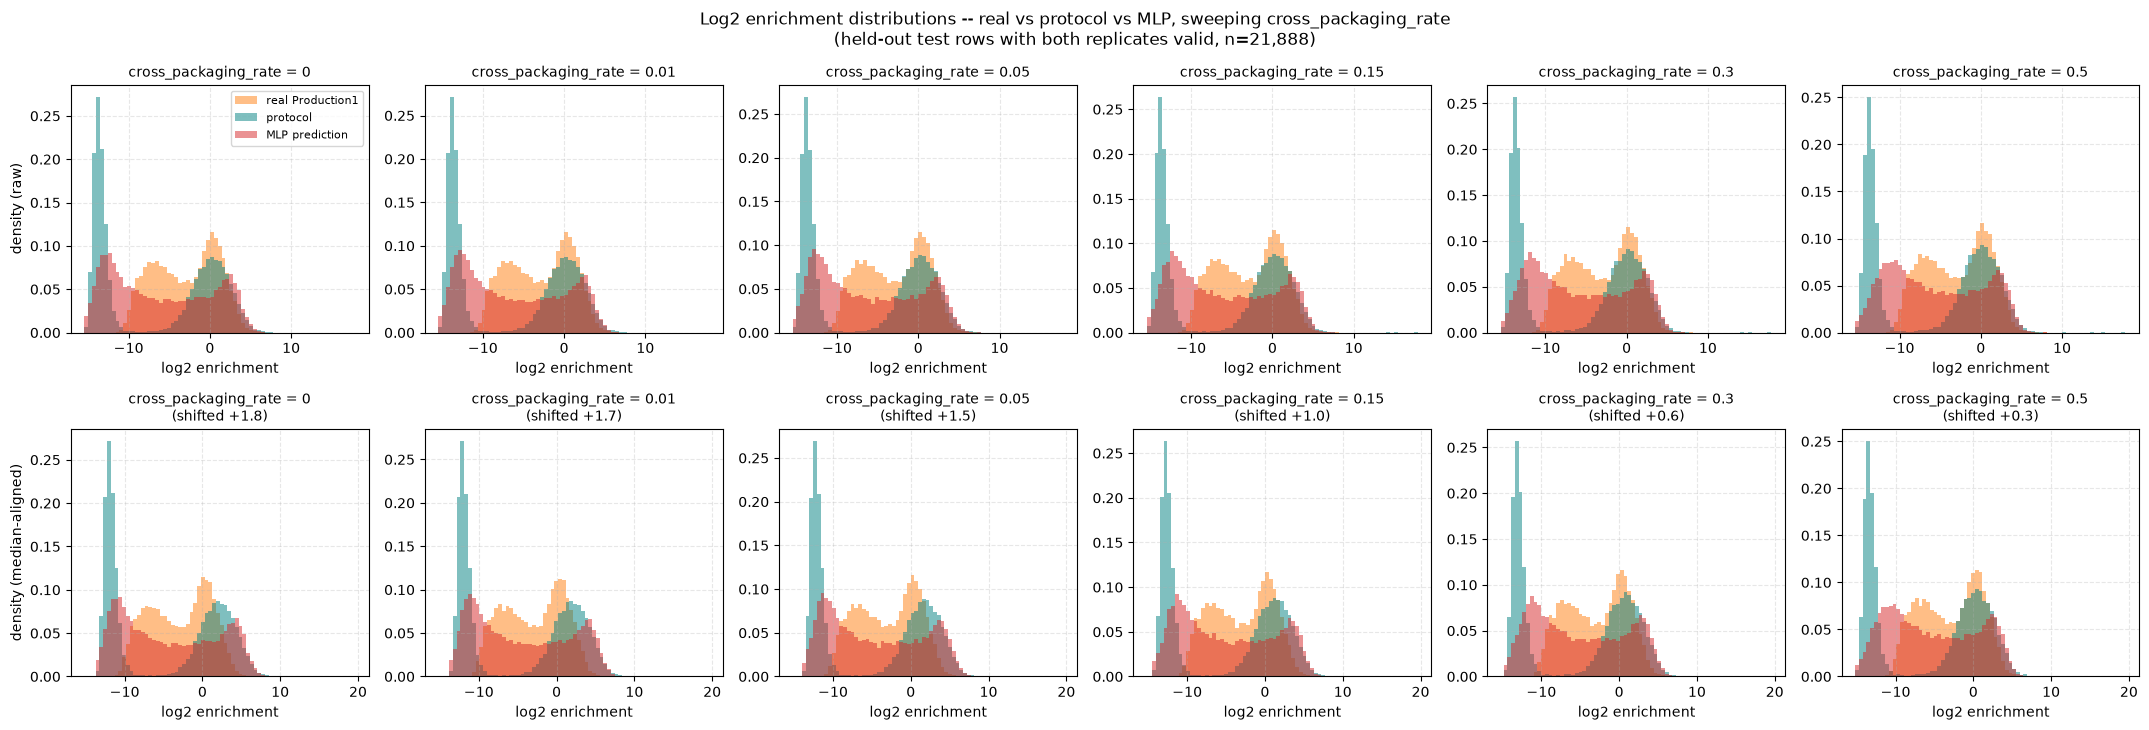

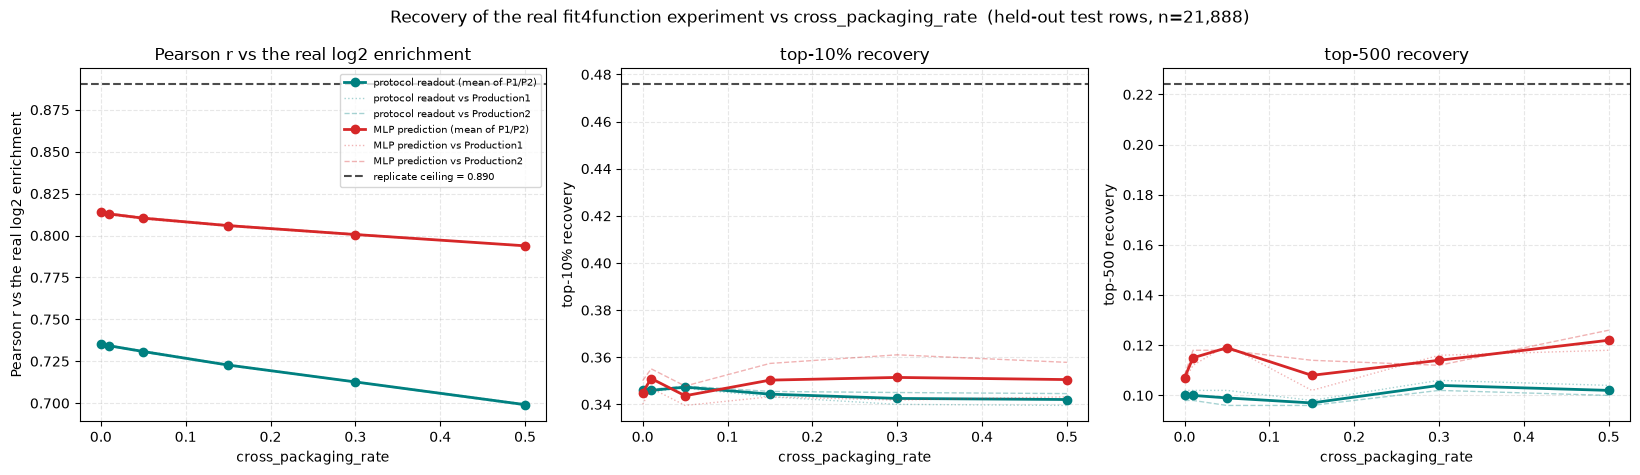

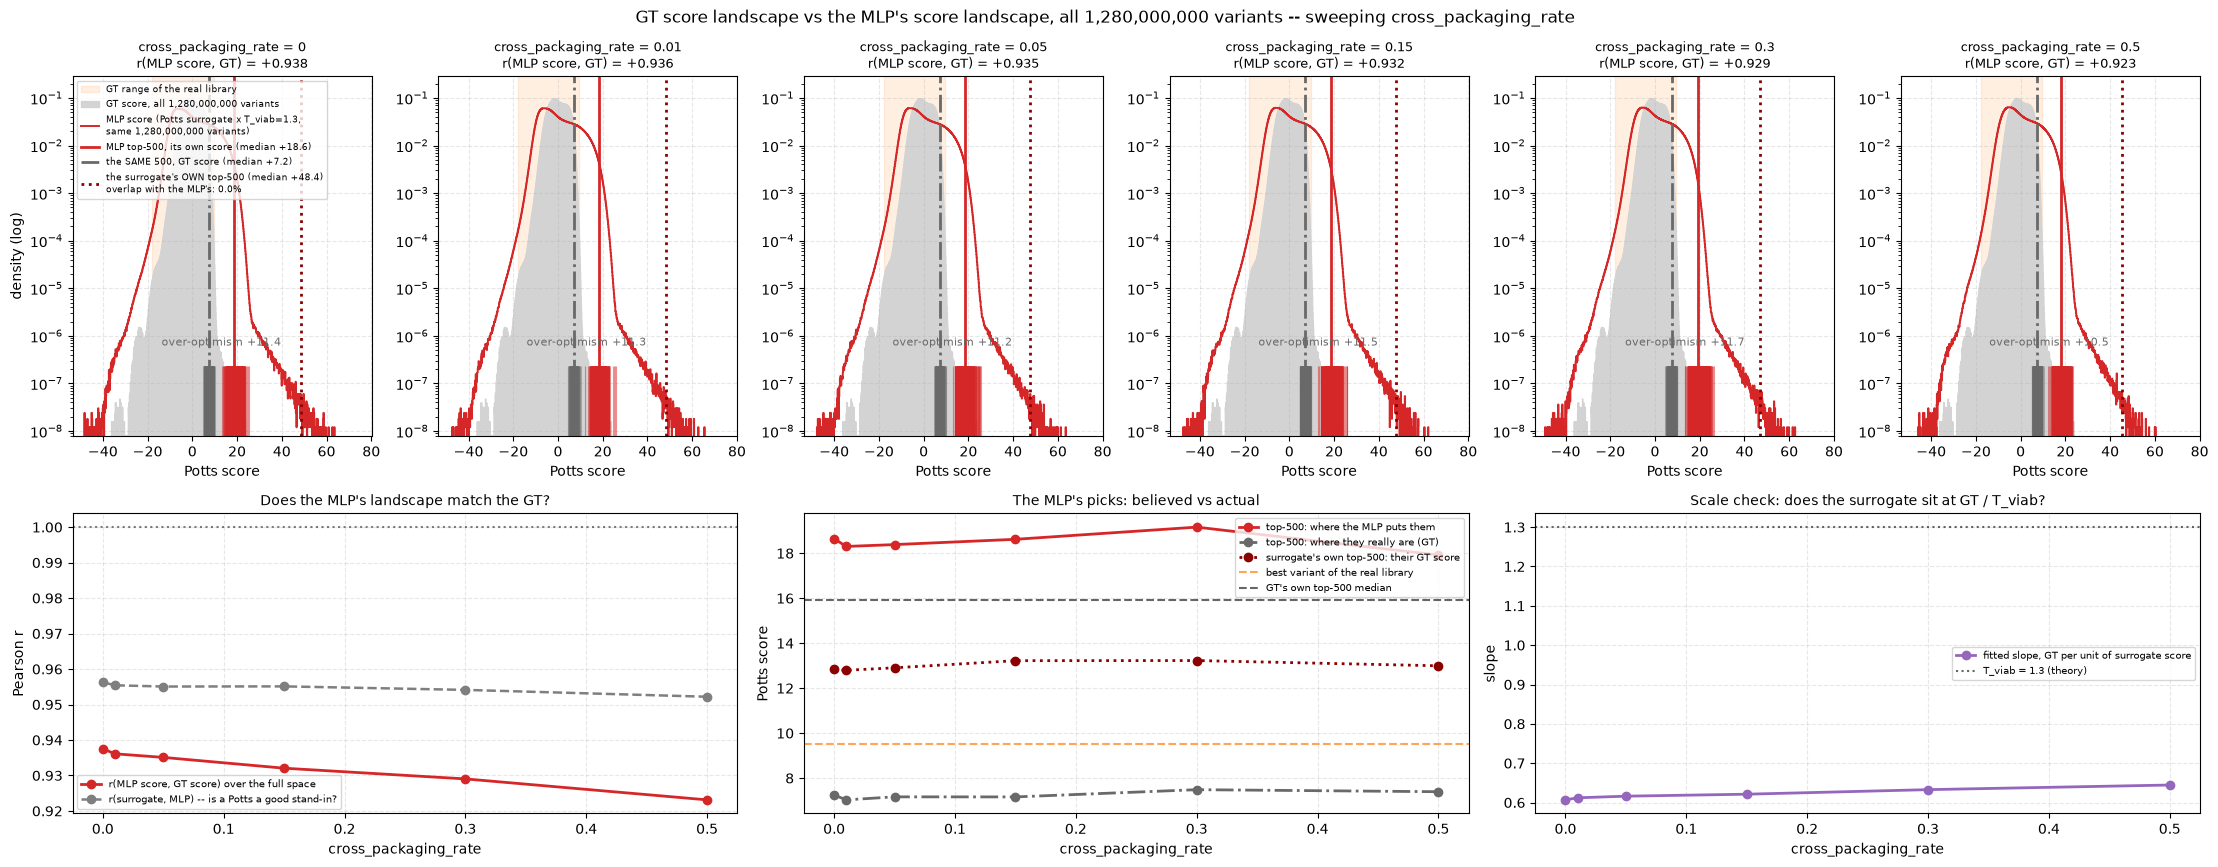

In [34]:
show_sweep(res_cross_packaging_rate, "cross_packaging_rate", logx=False)

## 6. Sweep B -- `mu` (transfected HEK cells per sequence)

`mu = rho * N1 / d0`, set here through `N1 = mu * d0 / rho` with `N0 = 150 * N1`. It is the
multiplicity of the transfection step: how many independent HEK cells each library member gets
to try its luck in. Low `mu` means each variant's outcome is decided by a handful of cells, so
the per-cell `noise_viab` lottery dominates; high `mu` averages that lottery out.

The grid stops at `mu=200` (`N0 = 2.2e12`): `N0 = 150 * N1` grows linearly with `mu`, and
`CLAUDE.md` puts the practical ceiling on `N0` at roughly `5e12`.

In [35]:
GRID_MU = [1, 5, 10, 25, 50, 100, 200]
res_mu = run_sweep("mu", GRID_MU)
summarize(res_mu)

=== sweep: mu  (everything else at baseline {'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 1000000000.0, 'cross_packaging_rate': 0.05}) ===


  mu=1          r_proto=+0.171 r_mlp=+0.331 prec10_proto=0.238 prec10_mlp=0.259 | GT median of MLP top-500 = +7.82 (4,727,378 variants beat it)  r(MLP,GT) full space = +0.384  r(surrogate,GT) = +0.475  slope = 0.68 (T_viab = 1.3)  top-500 log-enr vs score overlap = 24.8%  [64s]


  mu=5          r_proto=+0.333 r_mlp=+0.557 prec10_proto=0.276 prec10_mlp=0.314 | GT median of MLP top-500 = +8.55 (896,463 variants beat it)  r(MLP,GT) full space = +0.631  r(surrogate,GT) = +0.717  slope = 0.57 (T_viab = 1.3)  top-500 log-enr vs score overlap = 4.2%  [64s]


  mu=10         r_proto=+0.455 r_mlp=+0.641 prec10_proto=0.279 prec10_mlp=0.323 | GT median of MLP top-500 = +7.98 (3,828,863 variants beat it)  r(MLP,GT) full space = +0.720  r(surrogate,GT) = +0.797  slope = 0.59 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [67s]


  mu=25         r_proto=+0.657 r_mlp=+0.769 prec10_proto=0.312 prec10_mlp=0.329 | GT median of MLP top-500 = +7.29 (14,134,454 variants beat it)  r(MLP,GT) full space = +0.852  r(surrogate,GT) = +0.902  slope = 0.60 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [69s]


  mu=50         r_proto=+0.731 r_mlp=+0.810 prec10_proto=0.347 prec10_mlp=0.344 | GT median of MLP top-500 = +7.17 (16,520,067 variants beat it)  r(MLP,GT) full space = +0.893  r(surrogate,GT) = +0.935  slope = 0.62 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [68s]


  mu=100        r_proto=+0.758 r_mlp=+0.829 prec10_proto=0.360 prec10_mlp=0.364 | GT median of MLP top-500 = +6.94 (22,113,267 variants beat it)  r(MLP,GT) full space = +0.921  r(surrogate,GT) = +0.955  slope = 0.63 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [70s]


  mu=200        r_proto=+0.773 r_mlp=+0.835 prec10_proto=0.366 prec10_mlp=0.374 | GT median of MLP top-500 = +7.32 (12,007,193 variants beat it)  r(MLP,GT) full space = +0.936  r(surrogate,GT) = +0.964  slope = 0.64 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [69s]
=== done, 7.9 min ===


,param,value,r_proto,r_mlp,prec10_proto,prec10_mlp,top500_proto,top500_mlp,gt_median_mlp_top500,gt_recovery_top500,...,logenr_vs_score_overlap,r_surrogate_vs_gt,surrogate_slope,recovery_k500,recovery_k50000,recovery_k5000000,n_better_than_median,overlap_with_gt_top500,val_mse,elapsed_s
0,mu,1,0.1714,0.3312,0.2377,0.2591,0.101,0.084,7.8244,0.0,...,0.248,0.4746,0.6820,0.0000,0.0075,0.1652,4727378,0,44.7077,64.3513
1,mu,5,0.3331,0.5566,0.2756,0.3138,0.090,0.103,8.5477,0.0,...,0.042,0.7173,0.5692,0.1402,0.0547,0.2717,896463,0,71.2814,64.1685
2,mu,10,0.4549,0.6414,0.2793,0.3231,0.082,0.109,7.9816,0.0,...,0.000,0.7965,0.5894,0.1983,0.0606,0.2952,3828863,0,54.6325,67.0631
3,mu,25,0.6566,0.7688,0.3124,0.3291,0.060,0.096,7.2929,0.0,...,0.000,0.9021,0.6012,0.3229,0.0914,0.3497,14134454,0,20.6729,69.1035
4,mu,50,0.7308,0.8104,0.3473,0.3437,0.099,0.119,7.1679,0.0,...,0.000,0.9351,0.6162,0.3909,0.1446,0.4111,16520067,0,13.7389,68.2821
5,mu,100,0.7582,0.8295,0.3604,0.3643,0.120,0.122,6.9397,0.0,...,0.000,0.9548,0.6252,0.4549,0.1659,0.4377,22113267,0,12.3669,69.8796
6,mu,200,0.7730,0.8346,0.3656,0.3741,0.109,0.110,7.3197,0.0,...,0.000,0.9644,0.6437,0.5441,0.1849,0.4550,12007193,0,10.5778,69.4375


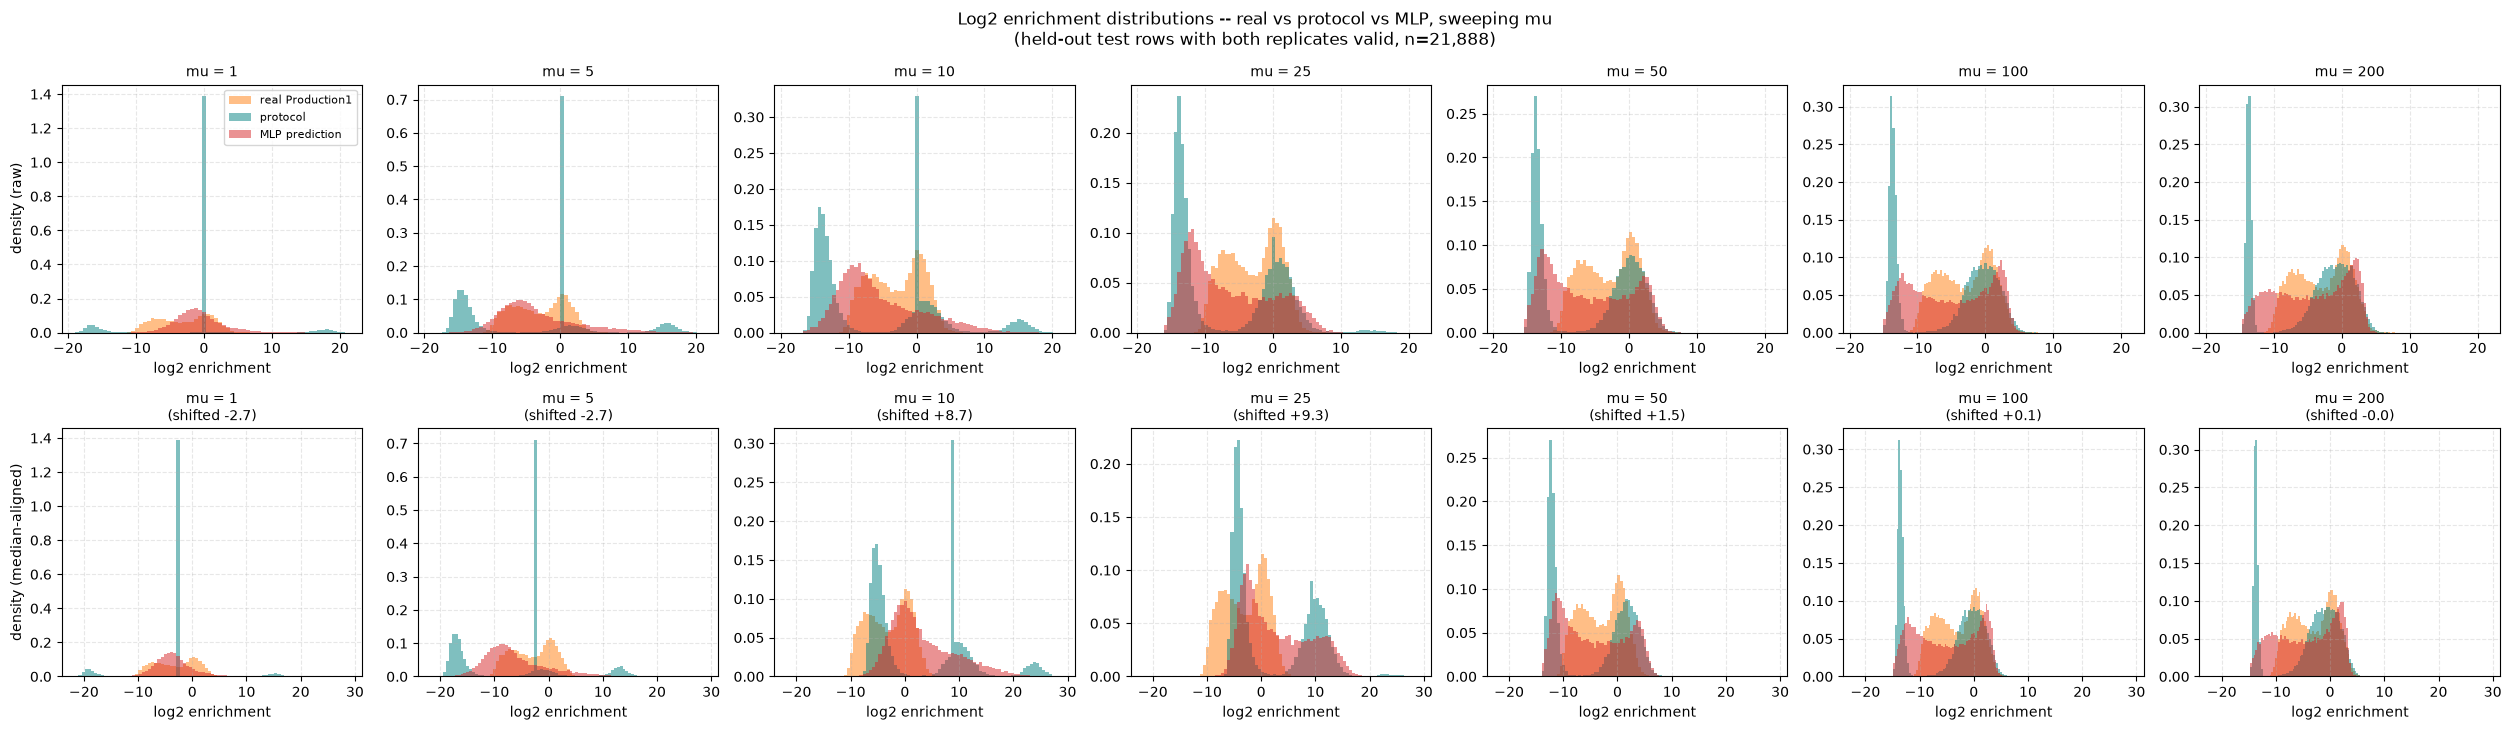

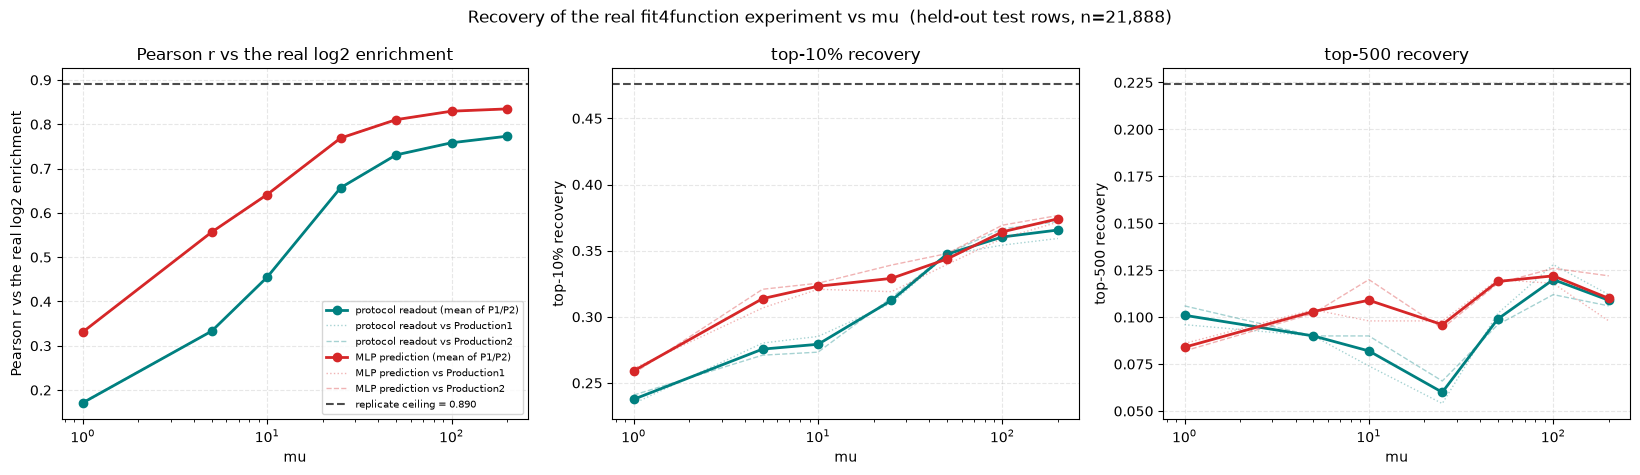

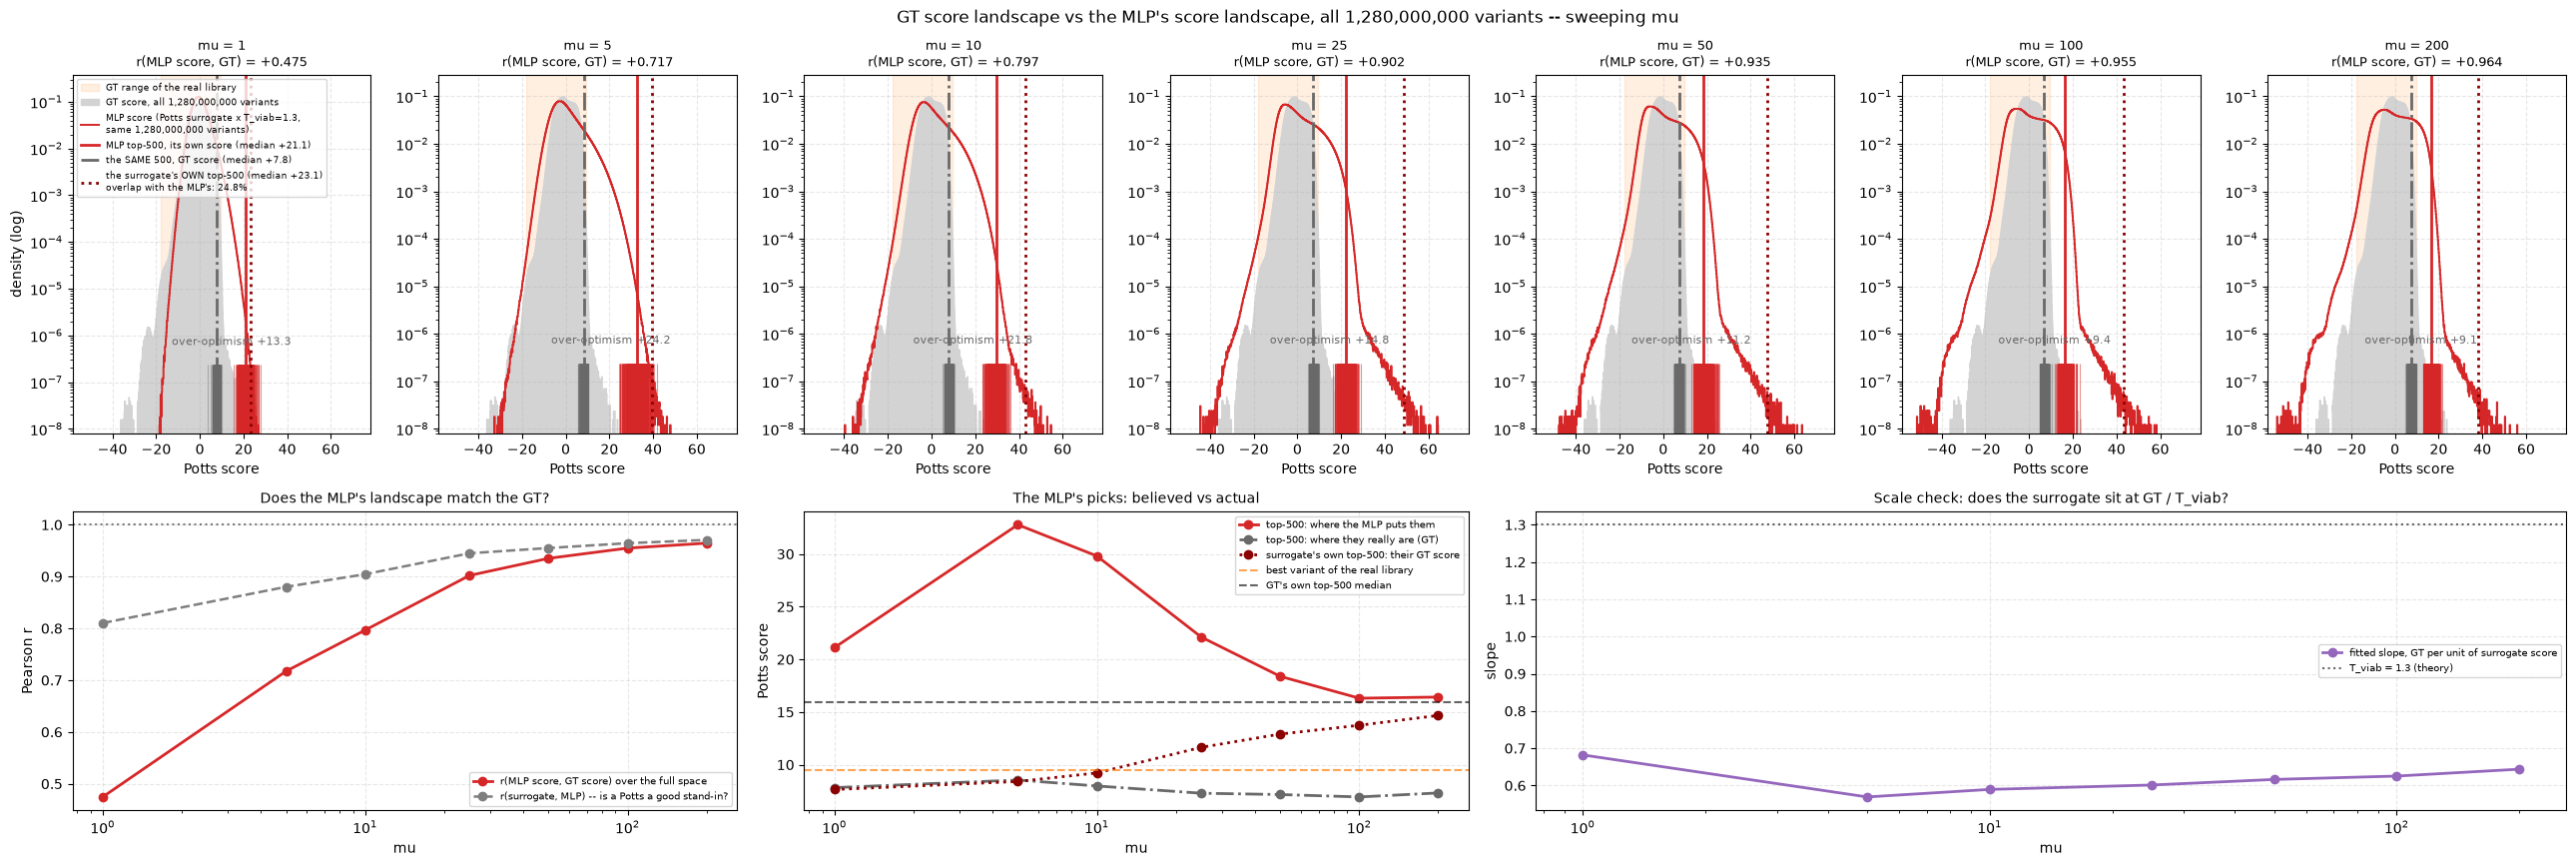

In [36]:
show_sweep(res_mu, "mu", logx=True)

## 7. Sweep C -- `T_viab` (viability selection temperature)

`T_viab` controls the sharpness of `exp(score / T_viab)` in `produce_capsids()`. Low
`T_viab` amplifies score differences **without** dividing the noise term, so the
signal-to-noise ratio explodes and the simulated distribution becomes near-deterministic
(diagnosed in `AAV9_fitting_protocol.ipynb`); high `T_viab` flattens selection until every
variant produces about the same number of capsids.

`1.3` is the baseline for the Potts GT. `0.8` is included as a reference point only because it
is the value that was derived for the OLD naive GT -- it is not the baseline here.

In [37]:
GRID_T_VIAB = [0.4, 0.8, 1.3, 2.0, 4.0, 8.0]
res_T_viab = run_sweep("T_viab", GRID_T_VIAB)
summarize(res_T_viab)

=== sweep: T_viab  (everything else at baseline {'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 1000000000.0, 'cross_packaging_rate': 0.05}) ===


  T_viab=0.4        r_proto=+0.654 r_mlp=+0.671 prec10_proto=0.360 prec10_mlp=0.354 | GT median of MLP top-500 = +10.17 (6,047 variants beat it)  r(MLP,GT) full space = +0.765  r(surrogate,GT) = +0.838  slope = 0.79 (T_viab = 0.4)  top-500 log-enr vs score overlap = 0.0%  [106s]


  T_viab=0.8        r_proto=+0.806 r_mlp=+0.824 prec10_proto=0.353 prec10_mlp=0.362 | GT median of MLP top-500 = +9.54 (40,324 variants beat it)  r(MLP,GT) full space = +0.902  r(surrogate,GT) = +0.939  slope = 0.63 (T_viab = 0.8)  top-500 log-enr vs score overlap = 0.0%  [73s]


  T_viab=1.3        r_proto=+0.731 r_mlp=+0.810 prec10_proto=0.347 prec10_mlp=0.344 | GT median of MLP top-500 = +7.17 (16,520,067 variants beat it)  r(MLP,GT) full space = +0.893  r(surrogate,GT) = +0.935  slope = 0.62 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [71s]


  T_viab=2          r_proto=+0.594 r_mlp=+0.753 prec10_proto=0.295 prec10_mlp=0.327 | GT median of MLP top-500 = +7.92 (3,828,863 variants beat it)  r(MLP,GT) full space = +0.857  r(surrogate,GT) = +0.905  slope = 0.66 (T_viab = 2.0)  top-500 log-enr vs score overlap = 0.0%  [70s]


  T_viab=4          r_proto=+0.316 r_mlp=+0.543 prec10_proto=0.202 prec10_mlp=0.269 | GT median of MLP top-500 = +7.88 (4,727,378 variants beat it)  r(MLP,GT) full space = +0.666  r(surrogate,GT) = +0.765  slope = 0.94 (T_viab = 4.0)  top-500 log-enr vs score overlap = 7.8%  [68s]


  T_viab=8          r_proto=+0.146 r_mlp=+0.298 prec10_proto=0.143 prec10_mlp=0.189 | GT median of MLP top-500 = +6.43 (41,189,984 variants beat it)  r(MLP,GT) full space = +0.384  r(surrogate,GT) = +0.492  slope = 0.88 (T_viab = 8.0)  top-500 log-enr vs score overlap = 3.4%  [69s]
=== done, 7.6 min ===


,param,value,r_proto,r_mlp,prec10_proto,prec10_mlp,top500_proto,top500_mlp,gt_median_mlp_top500,gt_recovery_top500,...,logenr_vs_score_overlap,r_surrogate_vs_gt,surrogate_slope,recovery_k500,recovery_k50000,recovery_k5000000,n_better_than_median,overlap_with_gt_top500,val_mse,elapsed_s
0,T_viab,0.4,0.6540,0.6714,0.3597,0.3540,0.110,0.099,10.1739,0.0,...,0.000,0.8376,0.7923,0.1881,0.1600,0.4171,6047,0,2.1718,106.4813
1,T_viab,0.8,0.8059,0.8243,0.3531,0.3622,0.107,0.114,9.5356,0.0,...,0.000,0.9395,0.6326,0.3856,0.1660,0.4387,40324,0,5.3178,72.8183
2,T_viab,1.3,0.7308,0.8104,0.3473,0.3437,0.099,0.119,7.1679,0.0,...,0.000,0.9351,0.6162,0.3909,0.1446,0.4111,16520067,0,13.7389,71.0246
3,T_viab,2.0,0.5941,0.7533,0.2948,0.3272,0.090,0.099,7.9168,0.0,...,0.000,0.9054,0.6606,0.3729,0.0920,0.3205,3828863,0,25.3262,70.0451
4,T_viab,4.0,0.3165,0.5435,0.2016,0.2687,0.063,0.082,7.8789,0.0,...,0.078,0.7649,0.9388,0.1361,0.0358,0.1823,4727378,0,38.7117,68.3410
5,T_viab,8.0,0.1464,0.2980,0.1431,0.1888,0.037,0.055,6.4281,0.0,...,0.034,0.4916,0.8834,0.0000,0.0017,0.0553,41189984,0,40.8968,69.4676


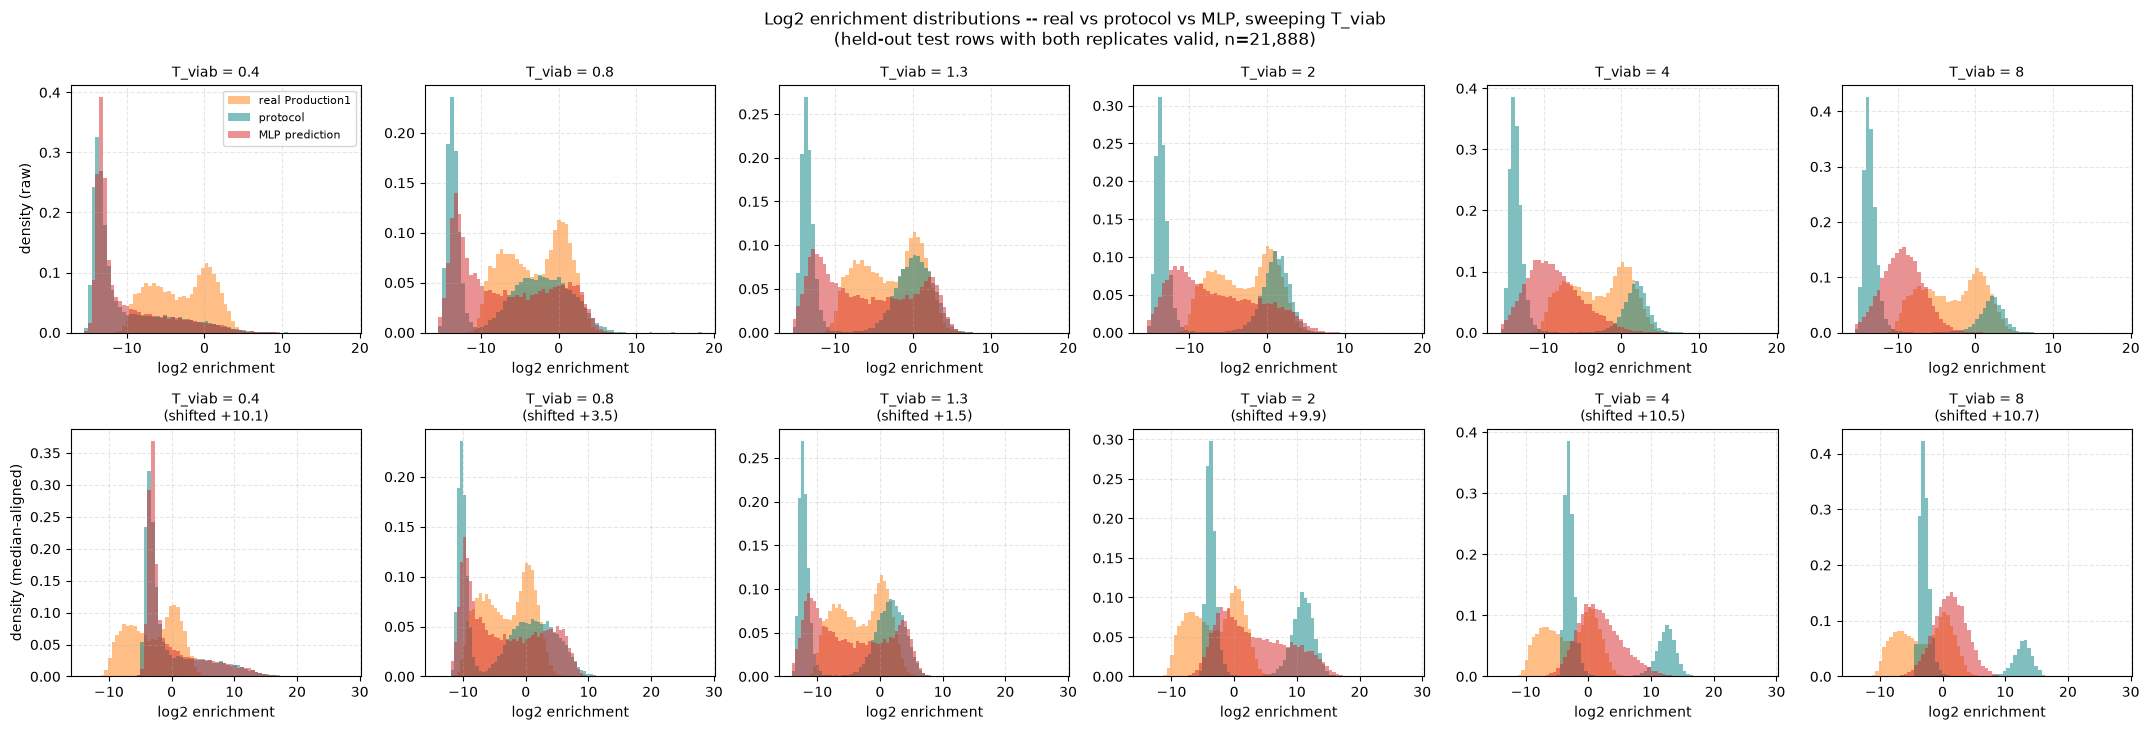

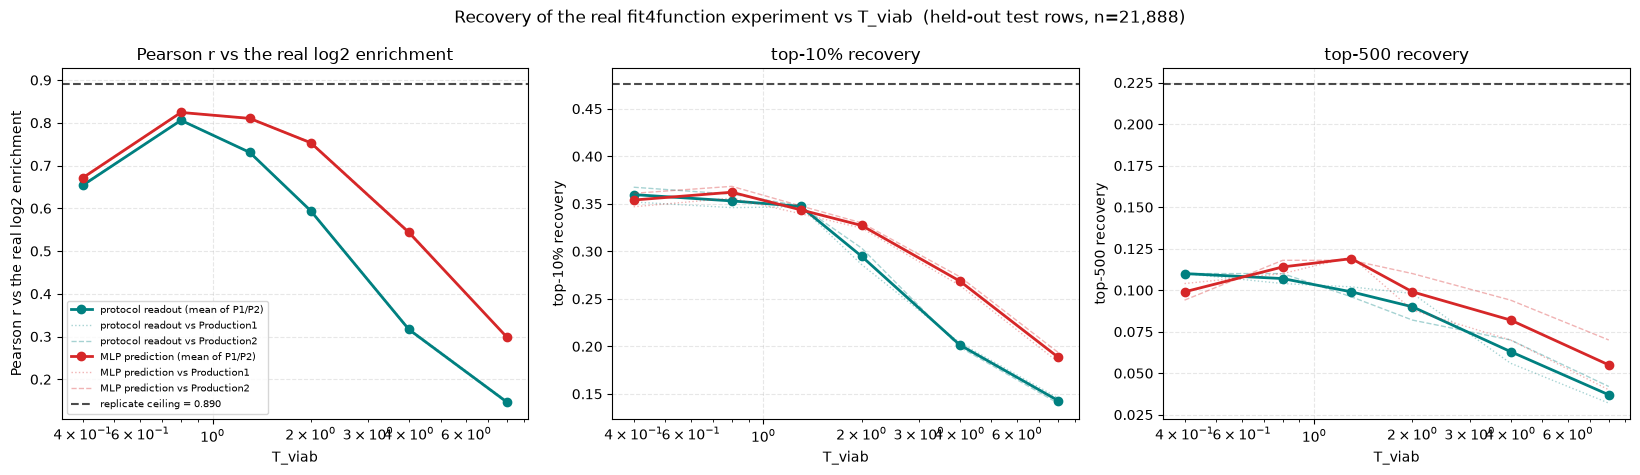

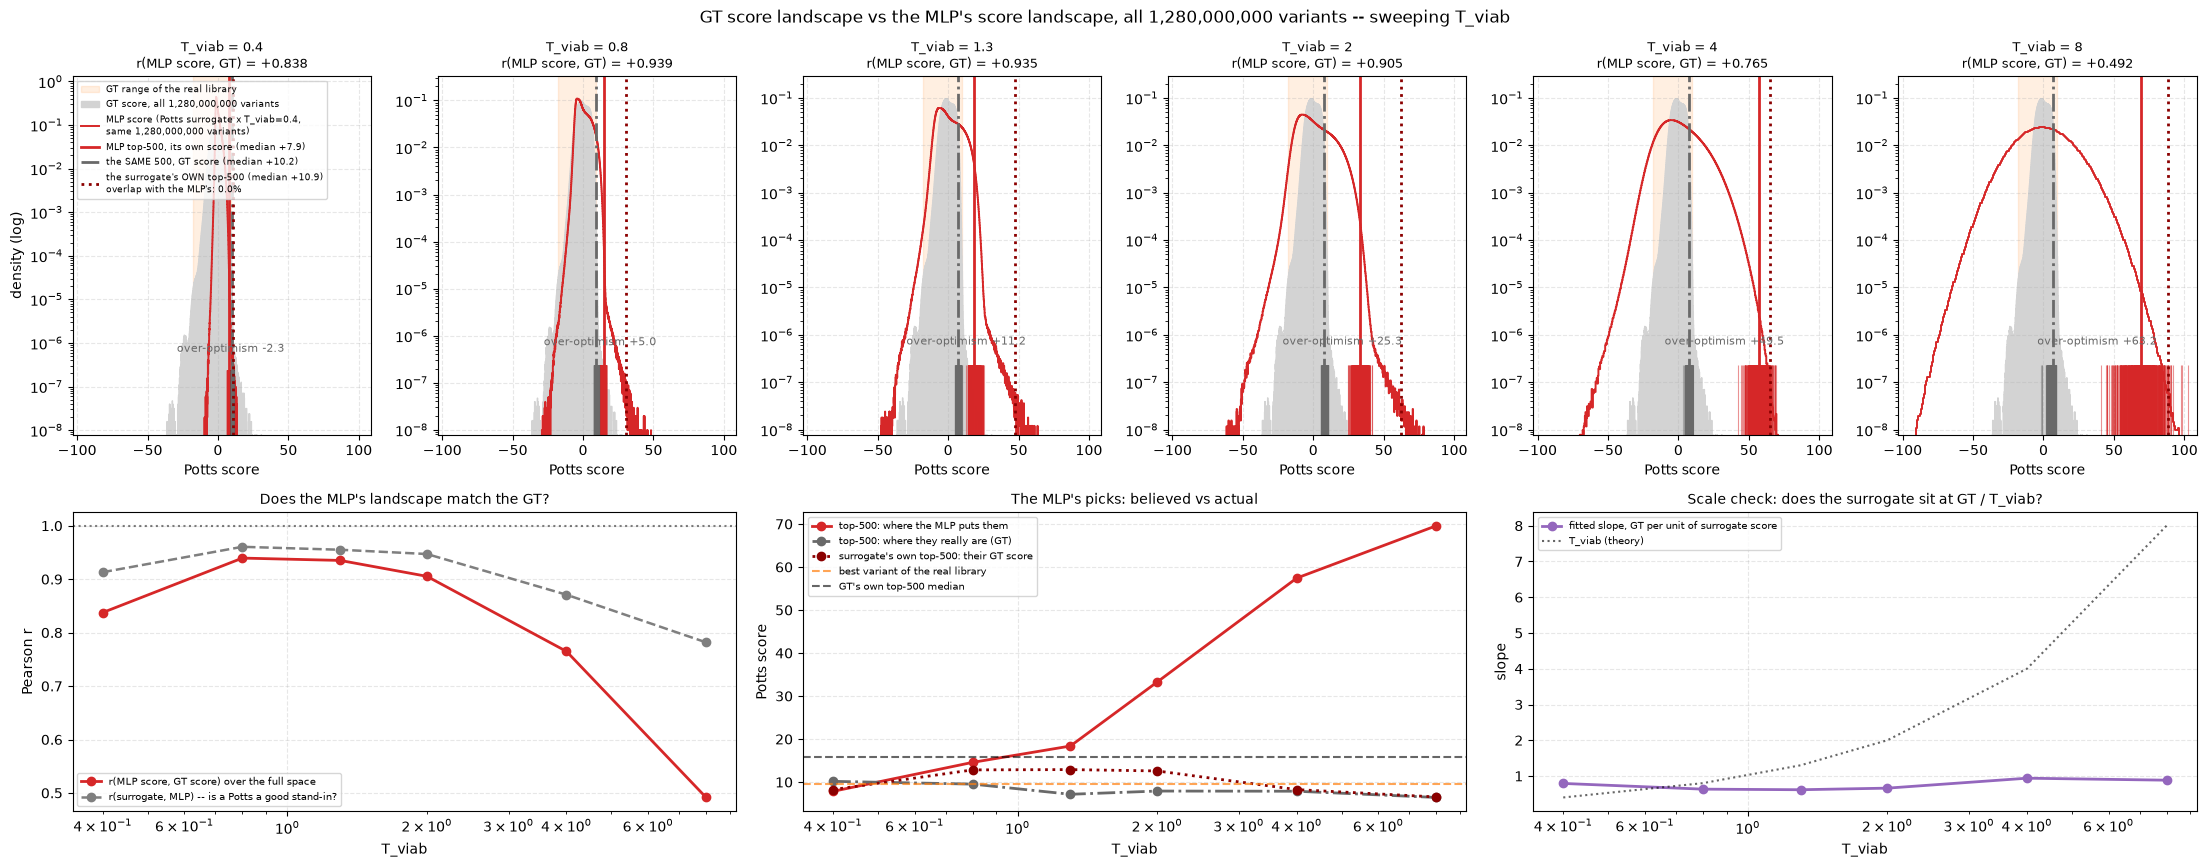

In [38]:
show_sweep(res_T_viab, "T_viab", logx=True)

## 8. Sweep D -- `noise_viab` (per-cell expression noise)

The log-normal per-cell noise `exp(noise_viab * Z / T_viab)` multiplying each transfected
cell's capsid production. `noise_viab = 0` removes it entirely, leaving only the NGS sampling
and Poisson production noise.

This is the sweep where the MLP's denoising claim is most directly testable: if the MLP really
recovers signal rather than memorizing the readout, its curve in figure 2 should stay above the
protocol's as `noise_viab` grows, and its picks in figure 3 should degrade more slowly.

In [39]:
GRID_NOISE_VIAB = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
res_noise_viab = run_sweep("noise_viab", GRID_NOISE_VIAB)
summarize(res_noise_viab)

=== sweep: noise_viab  (everything else at baseline {'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 1000000000.0, 'cross_packaging_rate': 0.05}) ===


  noise_viab=0          r_proto=+0.728 r_mlp=+0.806 prec10_proto=0.343 prec10_mlp=0.346 | GT median of MLP top-500 = +7.19 (16,520,067 variants beat it)  r(MLP,GT) full space = +0.889  r(surrogate,GT) = +0.931  slope = 0.62 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [71s]


  noise_viab=0.25       r_proto=+0.728 r_mlp=+0.808 prec10_proto=0.347 prec10_mlp=0.341 | GT median of MLP top-500 = +7.21 (14,134,454 variants beat it)  r(MLP,GT) full space = +0.891  r(surrogate,GT) = +0.933  slope = 0.61 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [72s]


  noise_viab=0.5        r_proto=+0.731 r_mlp=+0.810 prec10_proto=0.347 prec10_mlp=0.344 | GT median of MLP top-500 = +7.17 (16,520,067 variants beat it)  r(MLP,GT) full space = +0.893  r(surrogate,GT) = +0.935  slope = 0.62 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [74s]


  noise_viab=1          r_proto=+0.739 r_mlp=+0.815 prec10_proto=0.343 prec10_mlp=0.347 | GT median of MLP top-500 = +7.22 (14,134,454 variants beat it)  r(MLP,GT) full space = +0.901  r(surrogate,GT) = +0.941  slope = 0.62 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [75s]


  noise_viab=2          r_proto=+0.755 r_mlp=+0.828 prec10_proto=0.348 prec10_mlp=0.378 | GT median of MLP top-500 = +7.36 (12,007,193 variants beat it)  r(MLP,GT) full space = +0.926  r(surrogate,GT) = +0.957  slope = 0.63 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [71s]


  noise_viab=4          r_proto=+0.734 r_mlp=+0.820 prec10_proto=0.306 prec10_mlp=0.353 | GT median of MLP top-500 = +8.54 (896,463 variants beat it)  r(MLP,GT) full space = +0.949  r(surrogate,GT) = +0.969  slope = 0.89 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [71s]
=== done, 7.2 min ===


,param,value,r_proto,r_mlp,prec10_proto,prec10_mlp,top500_proto,top500_mlp,gt_median_mlp_top500,gt_recovery_top500,...,logenr_vs_score_overlap,r_surrogate_vs_gt,surrogate_slope,recovery_k500,recovery_k50000,recovery_k5000000,n_better_than_median,overlap_with_gt_top500,val_mse,elapsed_s
0,noise_viab,0.00,0.7277,0.8063,0.3428,0.3460,0.109,0.118,7.1905,0.0,...,0.0,0.9311,0.6153,0.3821,0.1360,0.3965,16520067,0,13.7031,71.0952
1,noise_viab,0.25,0.7279,0.8079,0.3469,0.3412,0.106,0.111,7.2122,0.0,...,0.0,0.9328,0.6105,0.3954,0.1380,0.3956,14134454,0,13.7053,72.4306
2,noise_viab,0.50,0.7308,0.8104,0.3473,0.3437,0.099,0.119,7.1679,0.0,...,0.0,0.9351,0.6162,0.3909,0.1446,0.4111,16520067,0,13.7389,73.7158
3,noise_viab,1.00,0.7393,0.8150,0.3426,0.3473,0.096,0.132,7.2201,0.0,...,0.0,0.9406,0.6169,0.4200,0.1435,0.4075,14134454,0,13.5360,74.5027
4,noise_viab,2.00,0.7549,0.8282,0.3476,0.3782,0.101,0.130,7.3635,0.0,...,0.0,0.9574,0.6348,0.5007,0.1701,0.4196,12007193,0,12.2234,71.3827
5,noise_viab,4.00,0.7343,0.8197,0.3064,0.3533,0.083,0.109,8.5418,0.0,...,0.0,0.9688,0.8863,0.7077,0.1698,0.4339,896463,0,7.2628,70.5122


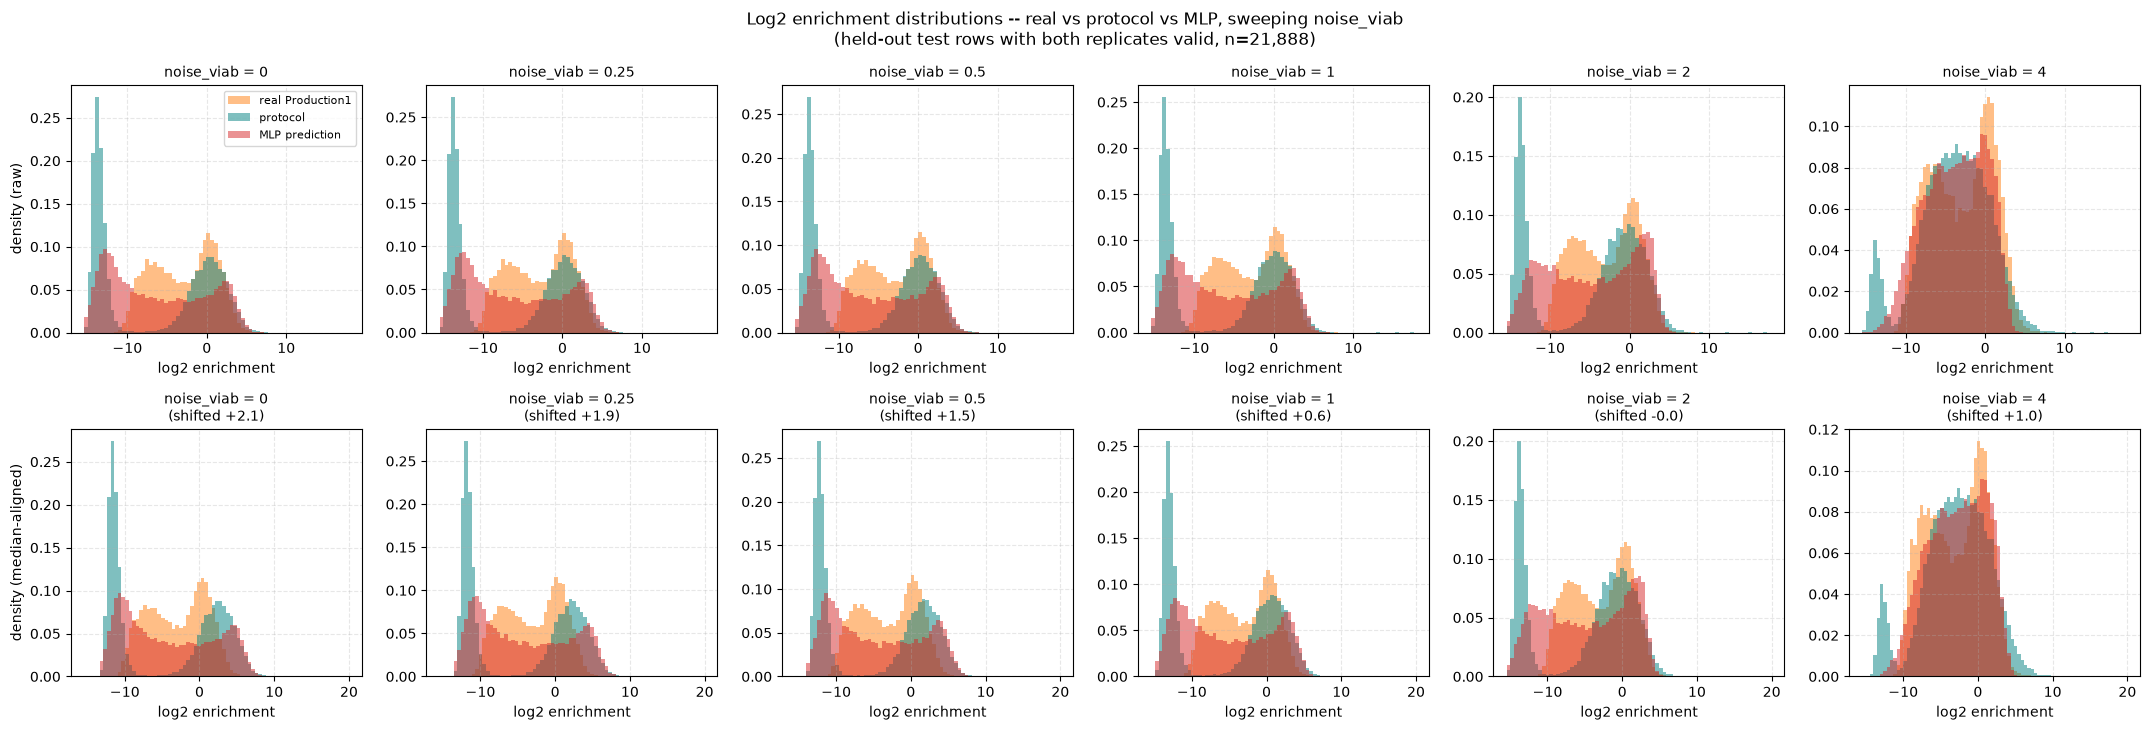

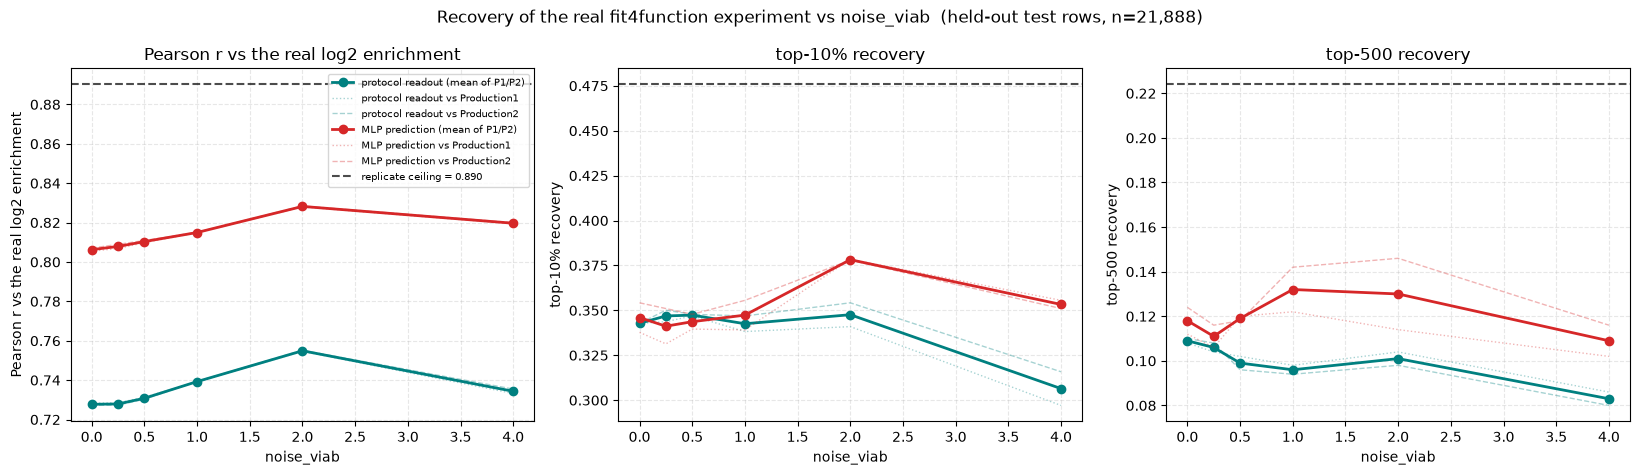

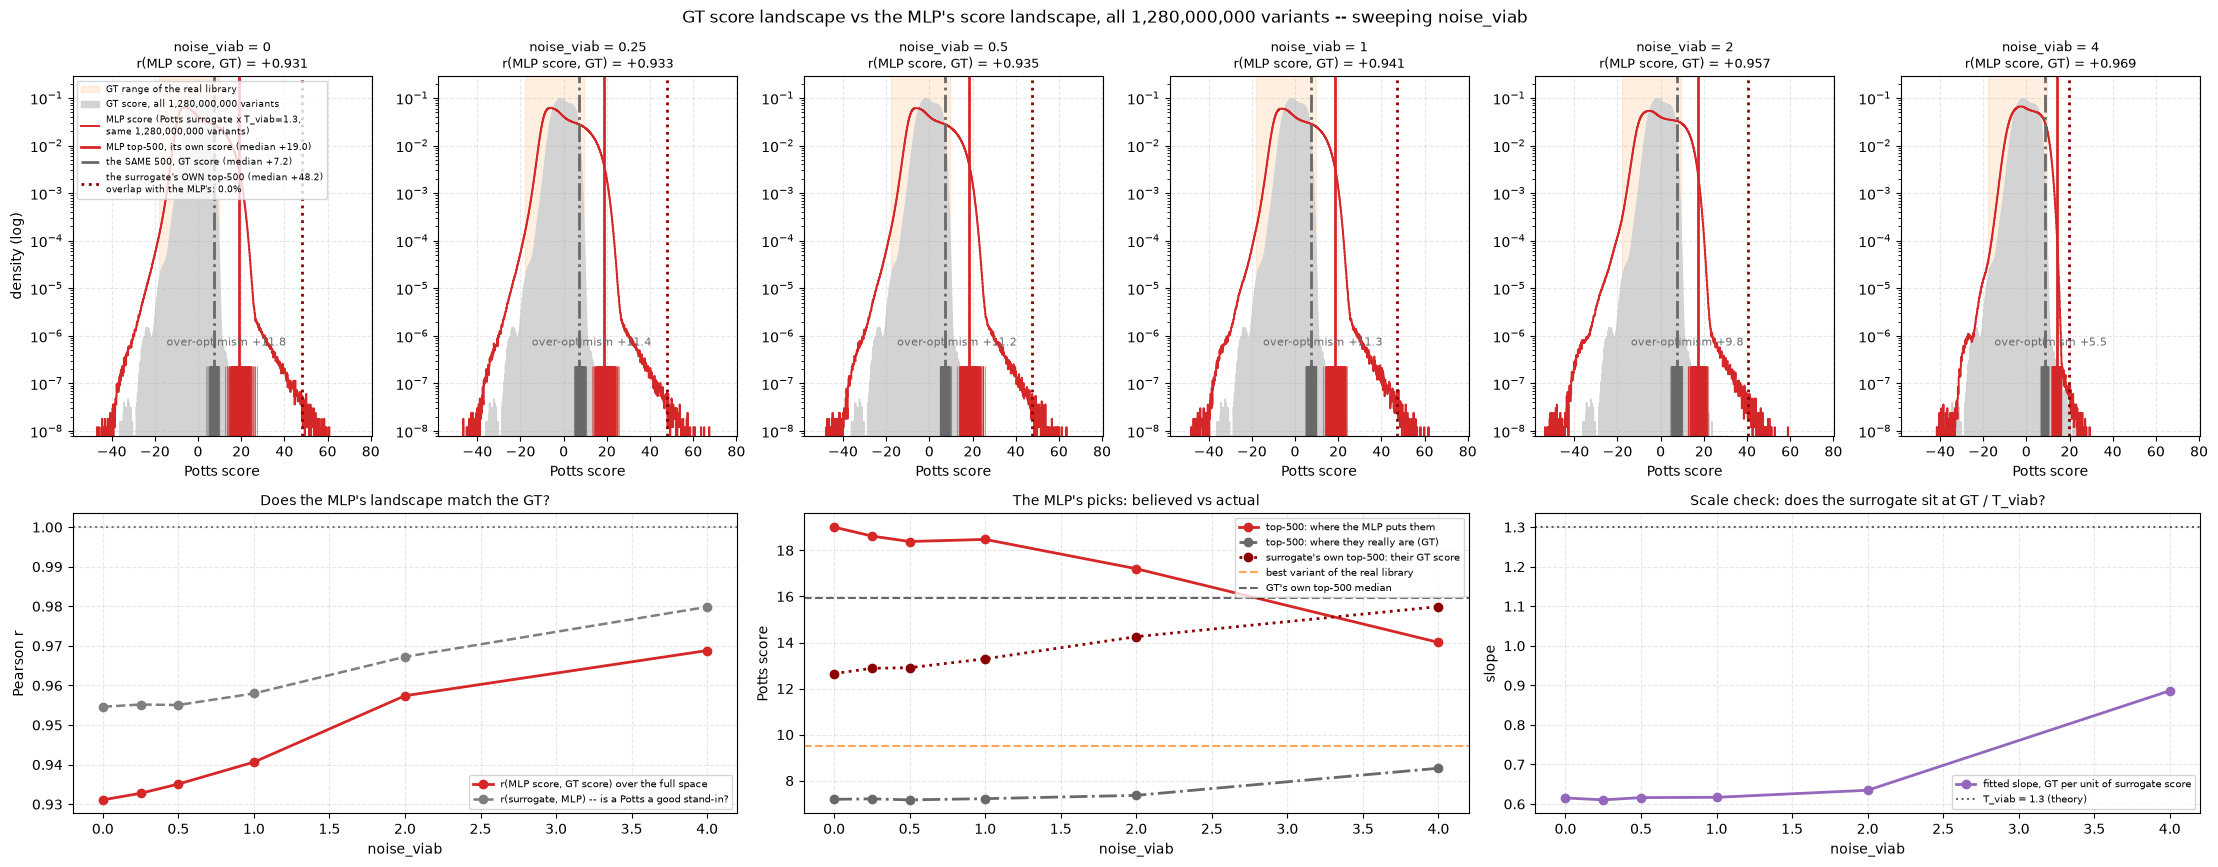

In [40]:
show_sweep(res_noise_viab, "noise_viab", logx=False)

## 9. Sweep E -- `D` (NGS sequencing depth per checkpoint)

Reads drawn per NGS checkpoint, `Multinomial(D, proportions)` since `multinomialNGS=True`.
At `d0 = 74,464` sequences this grid spans about 13 to 134,000 reads per sequence. Unlike
`T_viab`, this one has no pathological high end -- more reads can only help -- so the expected
shape is monotone with diminishing returns once the other noise sources dominate.

In [41]:
GRID_D = [1e6, 1e7, 1e8, 1e9]
res_D = run_sweep("D", GRID_D)
summarize(res_D)

=== sweep: D  (everything else at baseline {'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 1000000000.0, 'cross_packaging_rate': 0.05}) ===


  D=1e+06      r_proto=+0.676 r_mlp=+0.741 prec10_proto=0.339 prec10_mlp=0.336 | GT median of MLP top-500 = +9.70 (20,419 variants beat it)  r(MLP,GT) full space = +0.827  r(surrogate,GT) = +0.881  slope = 1.73 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [81s]


  D=1e+07      r_proto=+0.726 r_mlp=+0.789 prec10_proto=0.343 prec10_mlp=0.334 | GT median of MLP top-500 = +8.95 (283,636 variants beat it)  r(MLP,GT) full space = +0.872  r(surrogate,GT) = +0.916  slope = 1.10 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [74s]


  D=1e+08      r_proto=+0.733 r_mlp=+0.807 prec10_proto=0.346 prec10_mlp=0.351 | GT median of MLP top-500 = +8.14 (2,446,041 variants beat it)  r(MLP,GT) full space = +0.891  r(surrogate,GT) = +0.931  slope = 0.78 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [76s]


  D=1e+09      r_proto=+0.731 r_mlp=+0.810 prec10_proto=0.347 prec10_mlp=0.344 | GT median of MLP top-500 = +7.17 (16,520,067 variants beat it)  r(MLP,GT) full space = +0.893  r(surrogate,GT) = +0.935  slope = 0.62 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [75s]


  D=1e+10      r_proto=+0.727 r_mlp=+0.811 prec10_proto=0.347 prec10_mlp=0.344 | GT median of MLP top-500 = +6.55 (36,780,420 variants beat it)  r(MLP,GT) full space = +0.894  r(surrogate,GT) = +0.937  slope = 0.51 (T_viab = 1.3)  top-500 log-enr vs score overlap = 0.0%  [74s]
=== done, 6.3 min ===


,param,value,r_proto,r_mlp,prec10_proto,prec10_mlp,top500_proto,top500_mlp,gt_median_mlp_top500,gt_recovery_top500,...,logenr_vs_score_overlap,r_surrogate_vs_gt,surrogate_slope,recovery_k500,recovery_k50000,recovery_k5000000,n_better_than_median,overlap_with_gt_top500,val_mse,elapsed_s
0,D,1.000000e+06,0.6759,0.7411,0.3389,0.3359,0.089,0.097,9.7049,0.0,...,0.0,0.8808,1.7330,0.2925,0.1450,0.4162,20419,0,1.7701,81.1345
1,D,1.000000e+07,0.7260,0.7885,0.3435,0.3336,0.096,0.096,8.9545,0.0,...,0.0,0.9160,1.1021,0.3700,0.1434,0.3994,283636,0,3.7903,74.0627
2,D,1.000000e+08,0.7328,0.8068,0.3457,0.3508,0.097,0.111,8.1372,0.0,...,0.0,0.9314,0.7850,0.3780,0.1648,0.4193,2446041,0,7.7785,76.3391
3,D,1.000000e+09,0.7308,0.8104,0.3473,0.3437,0.099,0.119,7.1679,0.0,...,0.0,0.9351,0.6162,0.3909,0.1446,0.4111,16520067,0,13.7389,74.8826
4,D,1.000000e+10,0.7273,0.8108,0.3469,0.3437,0.099,0.115,6.5533,0.0,...,0.0,0.9371,0.5056,0.4020,0.1350,0.3884,36780420,0,21.7412,73.9534


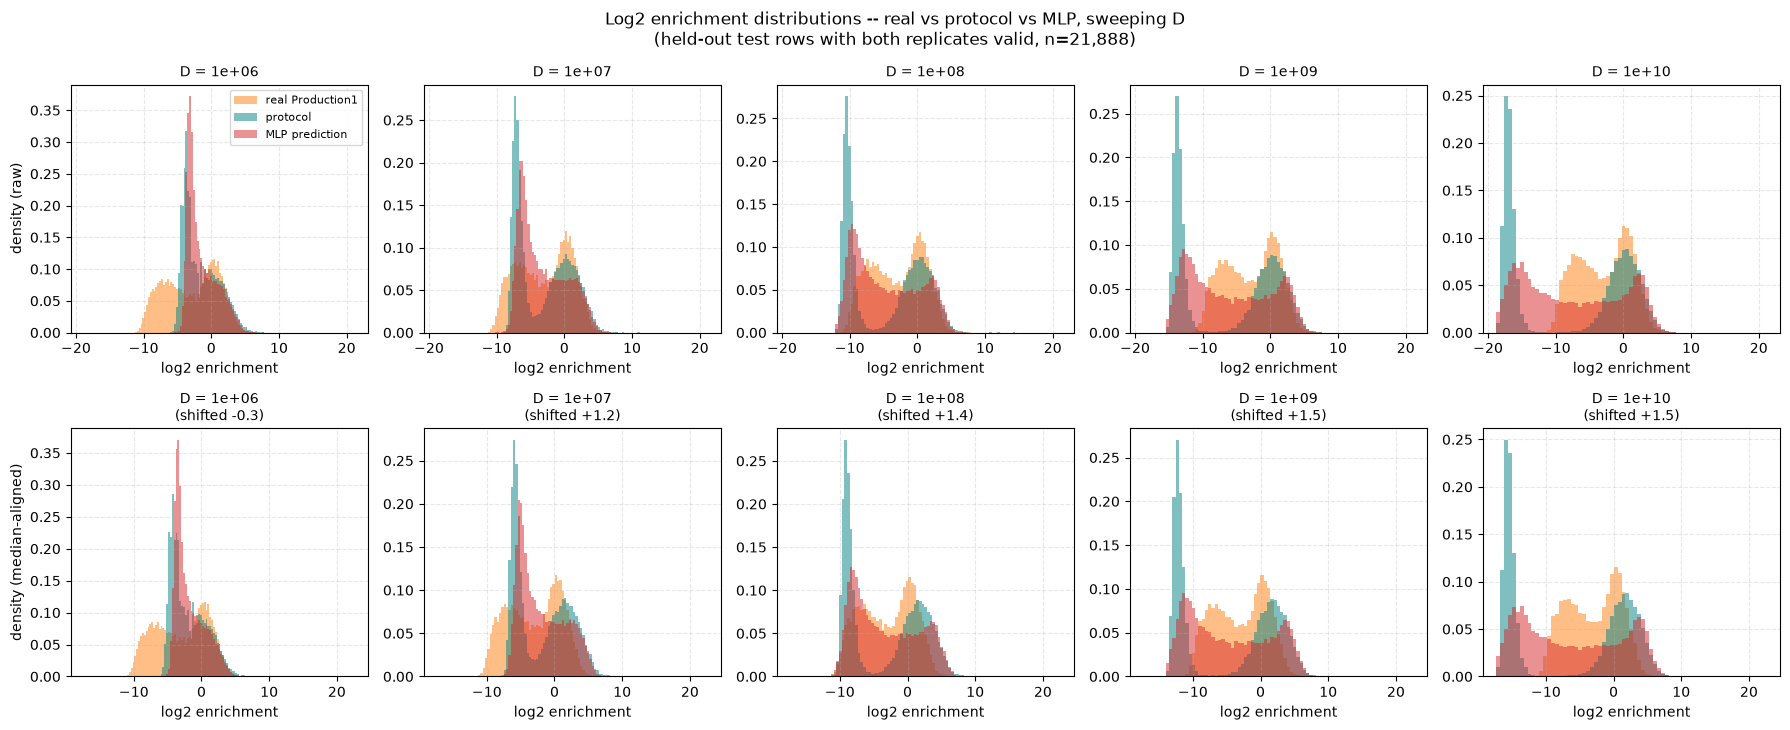

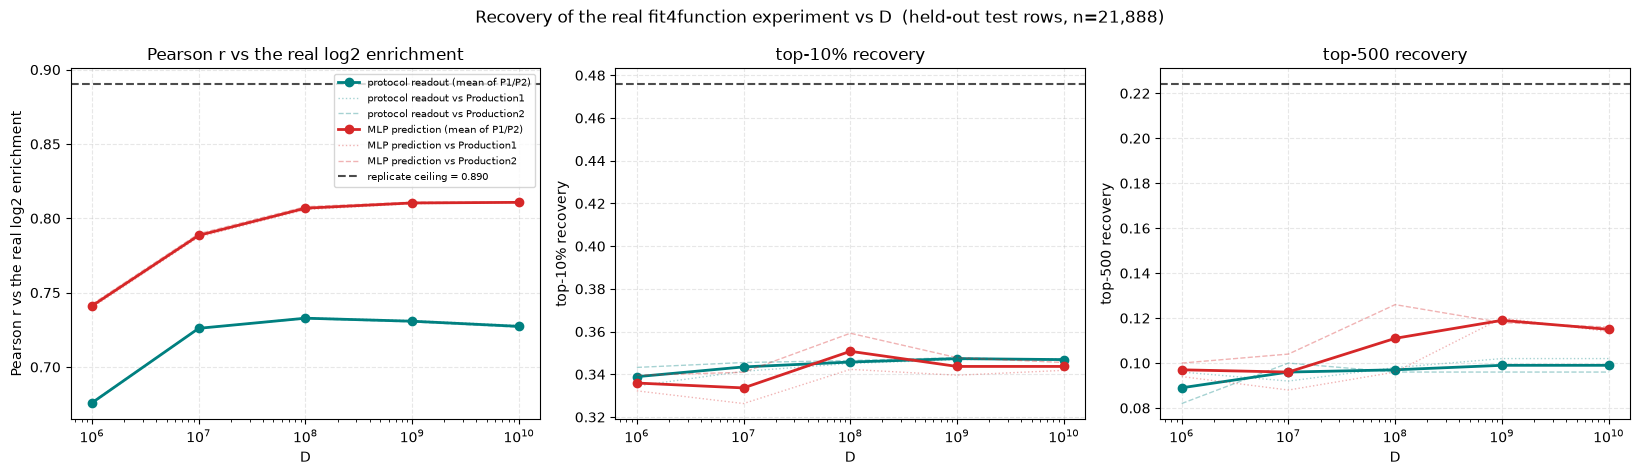

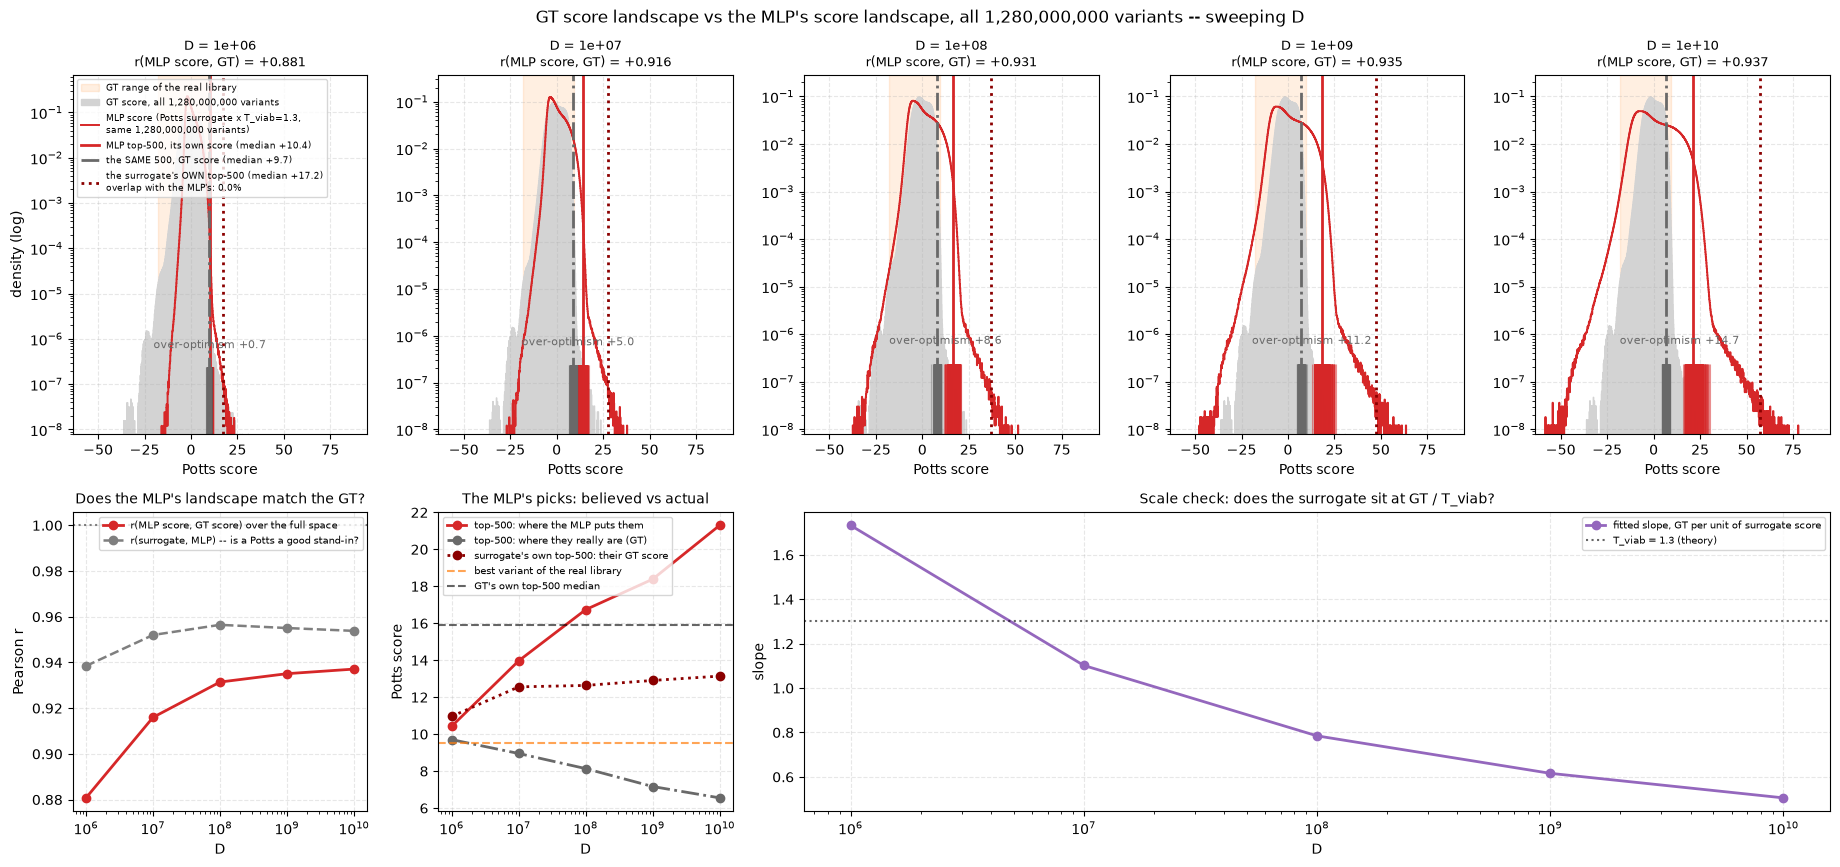

In [42]:
show_sweep(res_D, "D", logx=True)

## 10. All sweeps together

One tidy table across every sweep point run above, dumped next to the notebook so the numbers
survive a kernel restart without re-running the whole thing (~30 min on GPU). Nothing is ever
re-loaded from this file automatically -- it is an export, not a cache, so a stale copy can
never silently substitute itself for a fresh run (the trap `CLAUDE.md` records for the
`diversity*.csv` caches).

In [43]:
all_results = (summarize(res_cross_packaging_rate).assign(sweep="cross_packaging_rate")
               .pipe(lambda d: pd.concat([d,
                     summarize(res_mu).assign(sweep="mu"),
                     summarize(res_T_viab).assign(sweep="T_viab"),
                     summarize(res_noise_viab).assign(sweep="noise_viab"),
                     summarize(res_D).assign(sweep="D")], ignore_index=True)))

all_results.to_csv("cross_packaging_parameter_sweeps_summary.csv", index=False)
print(f"{len(all_results)} sweep points -> cross_packaging_parameter_sweeps_summary.csv")
print(f"replicate ceiling: r={CEILING['r']:.4f}  top-10%={CEILING['prec10']:.4f}  "
      f"top-500={CEILING['top500']:.4f}")
all_results

30 sweep points -> cross_packaging_parameter_sweeps_summary.csv
replicate ceiling: r=0.8902  top-10%=0.4758  top-500=0.2240


,param,value,r_proto,r_mlp,prec10_proto,prec10_mlp,top500_proto,top500_mlp,gt_median_mlp_top500,gt_recovery_top500,...,r_surrogate_vs_gt,surrogate_slope,recovery_k500,recovery_k50000,recovery_k5000000,n_better_than_median,overlap_with_gt_top500,val_mse,elapsed_s,sweep
0,cross_packaging_rate,0.000000e+00,0.7354,0.8142,0.3462,0.3451,0.100,0.107,7.2485,0.0,...,0.9375,0.6068,0.3940,0.1494,0.4055,14134454,0,13.1339,66.7093,cross_packaging_rate
1,cross_packaging_rate,1.000000e-02,0.7342,0.8129,0.3460,0.3510,0.100,0.115,7.0340,0.0,...,0.9361,0.6121,0.3949,0.1428,0.4042,19176146,0,13.2054,67.2259,cross_packaging_rate
2,cross_packaging_rate,5.000000e-02,0.7308,0.8104,0.3473,0.3437,0.099,0.119,7.1679,0.0,...,0.9351,0.6162,0.3909,0.1446,0.4111,16520067,0,13.7389,66.3677,cross_packaging_rate
3,cross_packaging_rate,1.500000e-01,0.7227,0.8059,0.3444,0.3503,0.097,0.108,7.1651,0.0,...,0.9321,0.6212,0.4105,0.1342,0.4023,16520067,0,14.6719,67.1648,cross_packaging_rate
4,cross_packaging_rate,3.000000e-01,0.7126,0.8006,0.3426,0.3515,0.104,0.114,7.4868,0.0,...,0.9290,0.6328,0.4174,0.1257,0.3974,10124907,0,16.1215,66.1261,cross_packaging_rate
5,cross_packaging_rate,5.000000e-01,0.6991,0.7939,0.3421,0.3505,0.102,0.122,7.3962,0.0,...,0.9231,0.6445,0.3991,0.1020,0.3703,12007193,0,17.6664,67.8305,cross_packaging_rate
6,mu,1.000000e+00,0.1714,0.3312,0.2377,0.2591,0.101,0.084,7.8244,0.0,...,0.4746,0.6820,0.0000,0.0075,0.1652,4727378,0,44.7077,64.3513,mu
7,mu,5.000000e+00,0.3331,0.5566,0.2756,0.3138,0.090,0.103,8.5477,0.0,...,0.7173,0.5692,0.1402,0.0547,0.2717,896463,0,71.2814,64.1685,mu
8,mu,1.000000e+01,0.4549,0.6414,0.2793,0.3231,0.082,0.109,7.9816,0.0,...,0.7965,0.5894,0.1983,0.0606,0.2952,3828863,0,54.6325,67.0631,mu
9,mu,2.500000e+01,0.6566,0.7688,0.3124,0.3291,0.060,0.096,7.2929,0.0,...,0.9021,0.6012,0.3229,0.0914,0.3497,14134454,0,20.6729,69.1035,mu


### 10b. Best point of each sweep

Ranked by the MLP's mean Pearson r against the two real replicates -- i.e. which value of each
parameter makes the simulated experiment behave most like the real one, as seen through the
model that is actually used downstream.

In [44]:
best = (all_results.sort_values("r_mlp", ascending=False)
                    .groupby("sweep", as_index=False).first()
                    .sort_values("r_mlp", ascending=False)
        [["sweep", "value", "r_proto", "r_mlp", "prec10_mlp", "top500_mlp",
          "gt_median_mlp_top500", "n_better_than_median"]])
print("best value of each swept parameter, by the MLP's mean r against Production1/Production2:")
print(f"(replicate ceiling r = {CEILING['r']:.4f} -- no method can be expected to beat it)")
best

best value of each swept parameter, by the MLP's mean r against Production1/Production2:
(replicate ceiling r = 0.8902 -- no method can be expected to beat it)


,sweep,value,r_proto,r_mlp,prec10_mlp,top500_mlp,gt_median_mlp_top500,n_better_than_median
3,mu,2.000000e+02,0.7730,0.8346,0.3741,0.110,7.3197,12007193
4,noise_viab,2.000000e+00,0.7549,0.8282,0.3782,0.130,7.3635,12007193
1,T_viab,8.000000e-01,0.8059,0.8243,0.3622,0.114,9.5356,40324
2,cross_packaging_rate,0.000000e+00,0.7354,0.8142,0.3451,0.107,7.2485,14134454
0,D,1.000000e+10,0.7273,0.8108,0.3437,0.115,6.5533,36780420


## 11. Top-k recovery: the MLP's score vs the GT's score

The question this whole notebook is built to answer, in one curve: **if you take the k best
variants according to the MLP and the k best according to the ground truth, how much do the two
sets overlap, as a function of k?**

Both rankings are Potts scores over the same 1.28e9 variants -- the GT's, and the MLP's via its
surrogate (section 4d) -- so this is a like-for-like comparison with no scale or noise mismatch.
`k` runs from a few tens to hundreds of millions.

The curve is read off the joint (GT score x surrogate score) table computed in `evaluate_point`,
which counts every variant of the full space in both rankings at once. That is exact at bin
resolution and costs one pass, where a running top-k would have to be redone for every k. Two
consequences of the bin grid worth knowing: `k` takes only the values the GT bin edges can
express (hence the irregular spacing), and the two top-k sets cannot be made exactly the same
size, so the denominator is the larger of them -- the recovery reported is the conservative one.

At large k the curve must approach 1 (both sets converge to the whole space); the informative
region is small k, where selection actually happens.

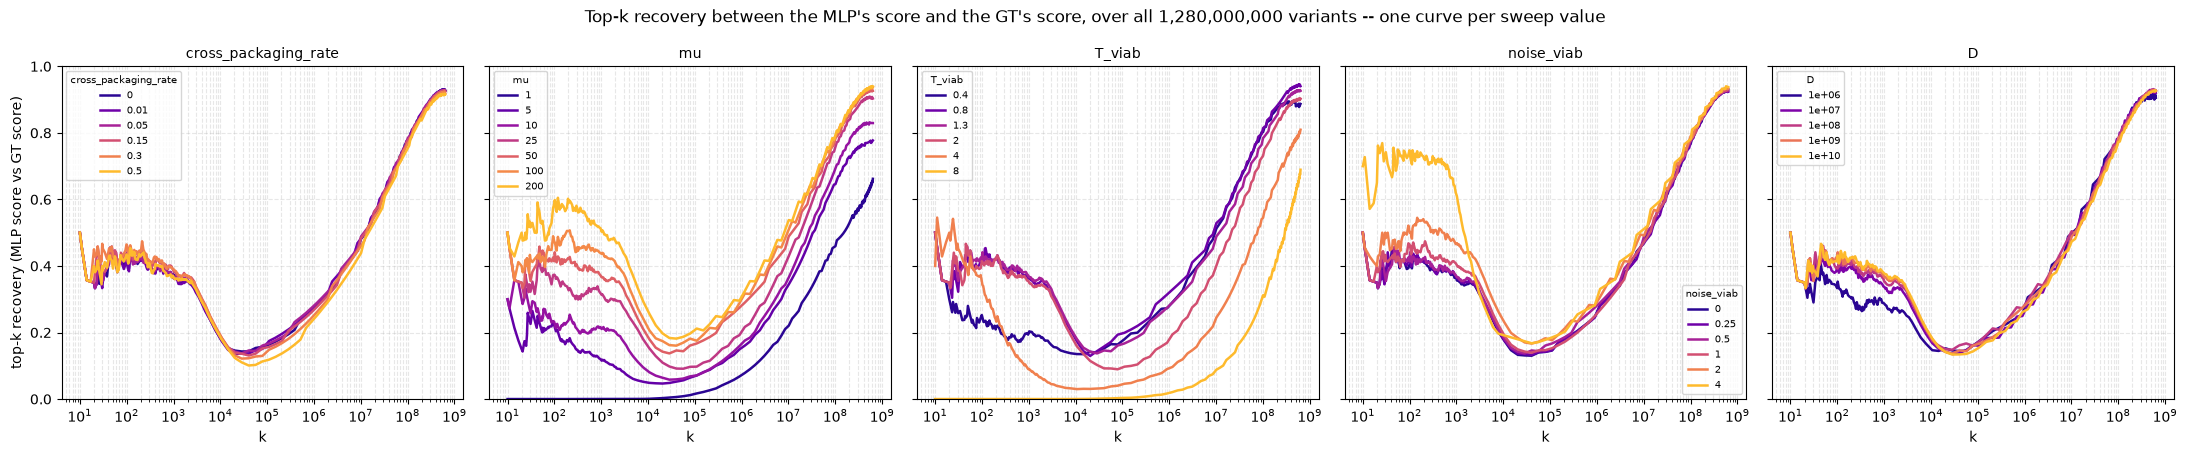

                 sweep      value          k=500        k=5,000       k=50,000      k=500,000    k=5,000,000
  cross_packaging_rate          0          0.394          0.263          0.149          0.238          0.406
  cross_packaging_rate       0.01          0.395          0.259          0.143          0.235          0.404
  cross_packaging_rate       0.05          0.391          0.266          0.145          0.244          0.411
  cross_packaging_rate       0.15          0.411          0.276          0.134          0.231          0.402
  cross_packaging_rate        0.3          0.417          0.276          0.126          0.209          0.397
  cross_packaging_rate        0.5          0.399          0.268          0.102          0.177          0.370
                    mu          1          0.000          0.000          0.008          0.049          0.165
                    mu          5          0.140          0.060          0.055          0.121          0.272
                   

In [45]:
SWEEPS_ALL = [("cross_packaging_rate", res_cross_packaging_rate, False),
              ("mu", res_mu, True), ("T_viab", res_T_viab, True),
              ("noise_viab", res_noise_viab, False), ("D", res_D, True)]

fig, axes = plt.subplots(1, 5, figsize=(22, 4.6), sharey=True)
for ax, (name, results, _logx) in zip(axes, SWEEPS_ALL):
    cmap = plt.cm.plasma(np.linspace(0.05, 0.85, len(results)))
    for res, color in zip(results, cmap):
        ax.plot(res["recovery_k"], res["recovery_curve"], "-", color=color, lw=1.8,
                label=f"{res['value']:.4g}")
    ax.set_xscale("log")
    ax.set_xlabel("k")
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=7, title=name, title_fontsize=7)
    ax.grid(True, which="both", ls="--", alpha=0.3)
axes[0].set_ylabel("top-k recovery (MLP score vs GT score)")
axes[0].set_ylim(0, 1)
fig.suptitle(f"Top-k recovery between the MLP's score and the GT's score, over all {TOTAL:,} "
             f"variants -- one curve per sweep value")
fig.tight_layout()
plt.show()

K_REPORT = [500, 5_000, 50_000, 500_000, 5_000_000]
print(f"{'sweep':>22s} {'value':>10s} " + " ".join(f"{'k=' + f'{k:,}':>14s}" for k in K_REPORT))
for name, results, _ in SWEEPS_ALL:
    for res in results:
        print(f"{name:>22s} {res['value']:>10.4g} "
              + " ".join(f"{recovery_at(res, k):>14.3f}" for k in K_REPORT))

### 11b. Recovery of the MLP's picks inside the GT's true global top-K

The other recovery worth having: are the MLP's 500 picks genuinely among the best variants that
exist? Reported at four depths, because at K=500 out of 1.28e9 the intersection is normally
empty -- the shallower depths show whether the picks are merely good or actually near-optimal.
The random baseline is `K / 1.28e9`, i.e. indistinguishable from zero at every depth shown.

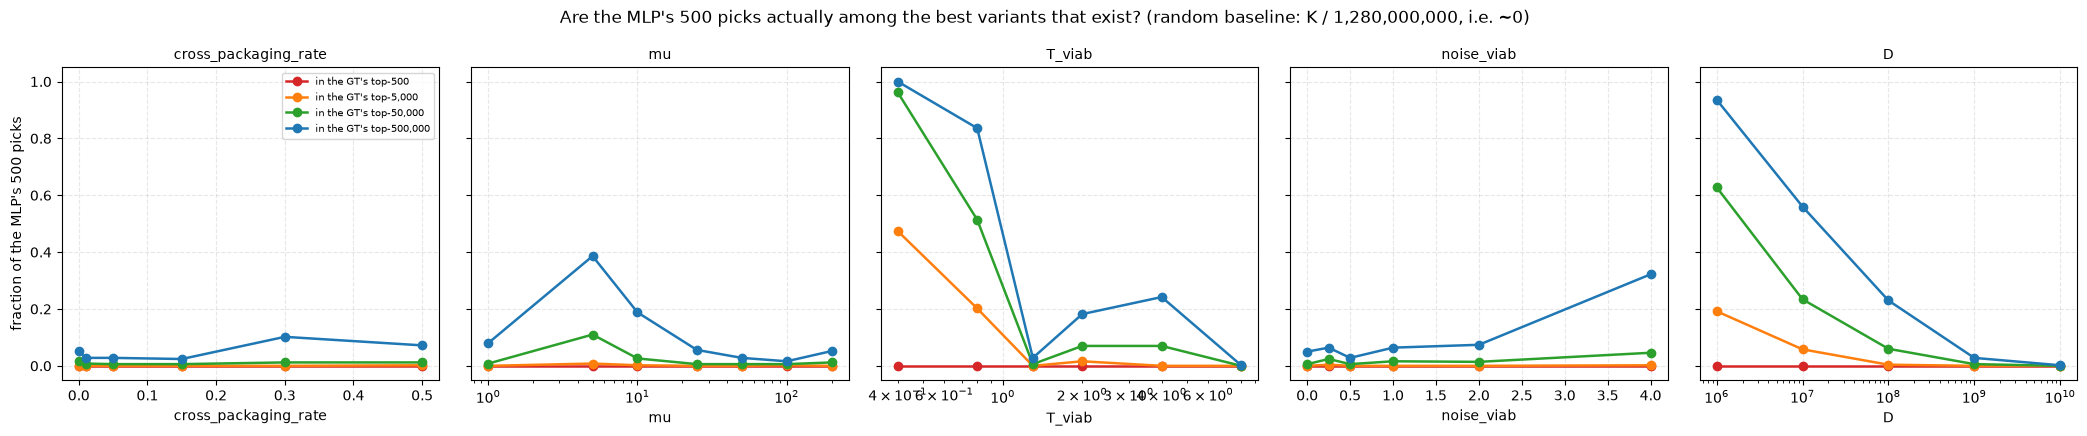

cross-check at K=500 -- histogram-threshold recovery vs exact set intersection:
  cross_packaging_rate   max |difference| = 0.0000
  mu                     max |difference| = 0.0000
  T_viab                 max |difference| = 0.0000
  noise_viab             max |difference| = 0.0000
  D                      max |difference| = 0.0000


In [46]:
fig, axes = plt.subplots(1, 5, figsize=(21, 4.4), sharey=True)
for ax, (name, res, logx) in zip(axes, [("cross_packaging_rate", res_cross_packaging_rate, False),
                                         ("mu", res_mu, True), ("T_viab", res_T_viab, True),
                                         ("noise_viab", res_noise_viab, False), ("D", res_D, True)]):
    x = np.array([r["value"] for r in res], dtype=float)
    for k, color in zip(GT_RECOVERY_DEPTHS, ["tab:red", "tab:orange", "tab:green", "tab:blue"]):
        ax.plot(x, [r[f"gt_recovery_top{k}"] for r in res], "o-", color=color, lw=1.8,
                label=f"in the GT's top-{k:,}")
    ax.set_xlabel(name)
    ax.set_title(name, fontsize=10)
    if logx:
        ax.set_xscale("log")
    ax.grid(True, ls="--", alpha=0.3)
axes[0].set_ylabel(f"fraction of the MLP's {TOP_K} picks")
axes[0].legend(fontsize=7.5)
fig.suptitle(f"Are the MLP's {TOP_K} picks actually among the best variants that exist? "
             f"(random baseline: K / {TOTAL:,}, i.e. ~0)")
fig.tight_layout()
plt.show()

print("cross-check at K=500 -- histogram-threshold recovery vs exact set intersection:")
for name, res in [("cross_packaging_rate", res_cross_packaging_rate), ("mu", res_mu),
                  ("T_viab", res_T_viab), ("noise_viab", res_noise_viab), ("D", res_D)]:
    diffs = [abs(r["gt_recovery_top500"] - r["gt_recovery_top500_exact"]) for r in res]
    print(f"  {name:22s} max |difference| = {max(diffs):.4f}")

## 12. Protocol recommendation

What to actually ask for in the lab. The recommendation is derived from the sweeps below rather
than written by hand, so re-running the notebook updates it.

**The criterion matters more than the ranking.** Two families of metric point in different
directions and answer different questions:

- `r_mlp`, `prec10_mlp`, `top500_mlp` (figure 2) measure how faithfully the *simulation*
  reproduces the *real* `fit4function` experiment. A high value means the simulator is
  realistic -- **not** that the protocol is good. Maximizing it would mean tuning the lab to
  reproduce the experiment we already have.
- `gt_recovery_*` and the median GT score of the picks (figures 3 and 11) measure how well the
  pipeline recovers the *underlying truth*. That is the project's actual goal -- finding the
  best variants -- so it is what the recommendation below optimizes.

Where the two disagree, the second one wins for a protocol decision, and the disagreement itself
is reported.

In [47]:
PRIMARY   = "gt_recovery_top50000"   # operational goal: are the picks genuinely near-optimal?
REALISM   = "r_mlp"                  # how closely the simulation matches the real experiment

rows = []
for name, res in [("cross_packaging_rate", res_cross_packaging_rate), ("mu", res_mu),
                  ("T_viab", res_T_viab), ("noise_viab", res_noise_viab), ("D", res_D)]:
    df_s   = summarize(res)
    best_p = df_s.loc[df_s[PRIMARY].idxmax()]
    best_r = df_s.loc[df_s[REALISM].idxmax()]
    rows.append(dict(
        parameter=name,
        recommended=best_p["value"], recommended_recovery=best_p[PRIMARY],
        recommended_r_mlp=best_p[REALISM],
        most_realistic=best_r["value"], most_realistic_recovery=best_r[PRIMARY],
        most_realistic_r_mlp=best_r[REALISM],
        agree=bool(best_p["value"] == best_r["value"]),
        # how much this parameter moves each metric across its whole grid = its leverage
        recovery_span=float(df_s[PRIMARY].max() - df_s[PRIMARY].min()),
        r_mlp_span=float(df_s[REALISM].max() - df_s[REALISM].min()),
    ))

reco = pd.DataFrame(rows).sort_values("recovery_span", ascending=False).reset_index(drop=True)

print("=" * 100)
print("PROTOCOL RECOMMENDATION -- parameters ordered by how much they move variant-discovery")
print(f"(primary criterion: {PRIMARY}; realism criterion shown alongside: {REALISM})")
print("=" * 100)
for _, r in reco.iterrows():
    verdict = "same value" if r["agree"] else (f"DISAGREES -- most realistic would be "
                                               f"{r['most_realistic']:.4g}")
    print(f"\n{r['parameter']:>22s} -> {r['recommended']:<10.4g}  "
          f"(recovery {r['recommended_recovery']:.3f}, r_mlp {r['recommended_r_mlp']:.3f})")
    print(f"{'':>22s}    leverage: recovery varies by {r['recovery_span']:.3f} across the grid, "
          f"r_mlp by {r['r_mlp_span']:.3f}")
    print(f"{'':>22s}    realism criterion: {verdict}")

print("\n" + "=" * 100)
print("Recommended configuration (each parameter at its best value, one at a time):")
print("   " + ", ".join(f"{r['parameter']}={r['recommended']:.4g}" for _, r in reco.iterrows()))
print(f"Replicate ceiling for reference: r = {CEILING['r']:.4f} "
      f"(no method can be expected to beat it on the realism axis)")
print("=" * 100)
print("""
CAVEATS -- read before taking any of this to the bench:
  * One parameter is varied at a time from a single baseline. Interactions are NOT explored, so
    the combined configuration above is an extrapolation, not a tested point. It should be run
    as its own simulation before being trusted.
  * One seed per sweep point. Differences smaller than the run-to-run spread are not real;
    AAV9_potts_simulated_replicate_stochasticity.ipynb is the notebook that quantifies that
    spread.
  * cross_packaging_rate is an illustrative, uncalibrated constant, not a measured rate. Its
    sweep says how sensitive the conclusions are to it, not what its true value is.
  * The baseline (mu=50, T_viab=1.3, noise_viab=0.5, D=1e9) comes from AAV9_fitting_protocol.ipynb,
    where mu/noise_viab/D were derived against the OLD naive GT and never re-derived against the
    Potts GT used here.
  * Lab feasibility bounds the grid: N0 = 150 * N1 grows linearly with mu, which is why mu stops
    at 200 (N0 = 2.2e12).
""")
reco.round(4)

PROTOCOL RECOMMENDATION -- parameters ordered by how much they move variant-discovery
(primary criterion: gt_recovery_top50000; realism criterion shown alongside: r_mlp)

                T_viab -> 0.4         (recovery 0.962, r_mlp 0.671)
                          leverage: recovery varies by 0.962 across the grid, r_mlp by 0.526
                          realism criterion: DISAGREES -- most realistic would be 0.8

                     D -> 1e+06       (recovery 0.628, r_mlp 0.741)
                          leverage: recovery varies by 0.628 across the grid, r_mlp by 0.070
                          realism criterion: DISAGREES -- most realistic would be 1e+10

                    mu -> 5           (recovery 0.110, r_mlp 0.557)
                          leverage: recovery varies by 0.104 across the grid, r_mlp by 0.503
                          realism criterion: DISAGREES -- most realistic would be 200

            noise_viab -> 4           (recovery 0.046, r_mlp 0.820)
               

,parameter,recommended,recommended_recovery,recommended_r_mlp,most_realistic,most_realistic_recovery,most_realistic_r_mlp,agree,recovery_span,r_mlp_span
0,T_viab,0.4,0.962,0.6714,8.000000e-01,0.514,0.8243,False,0.962,0.5263
1,D,1000000.0,0.628,0.7411,1.000000e+10,0.000,0.8108,False,0.628,0.0697
2,mu,5.0,0.110,0.5566,2.000000e+02,0.012,0.8346,False,0.104,0.5034
3,noise_viab,4.0,0.046,0.8197,2.000000e+00,0.014,0.8282,False,0.040,0.0219
4,cross_packaging_rate,0.0,0.016,0.8142,0.000000e+00,0.016,0.8142,True,0.010,0.0203
